# 3 · Análisis exploratorio de datos (EDA)

**Proyecto:** Predicción de readmisión hospitalaria en pacientes diabéticos
**Dataset:** *Diabetes 130-US hospitals for years 1999-2008* (UCI Machine Learning Repository)
**Autor:** Diego Rodríguez Díaz del Campo

---

### Objetivo de este notebook

Pasar de *describir* el dataset a *entenderlo*. El análisis no busca solo conocer la
forma de cada variable, sino responder a preguntas concretas:

- ¿Qué características se asocian con una readmisión?
- ¿Existen grupos de pacientes en los que la readmisión temprana (`<30`) sea
  especialmente frecuente?
- ¿Qué variables diferencian realmente `NO`, `>30` y `<30`?
- ¿Cuáles son candidatas prometedoras para el modelo y cuáles son redundantes?

| | |
|---|---|
| **Entrada** | `data/processed/diabetic_data_clean.csv` (101.766 × 35) |
| **Variable objetivo** | `readmitted` (`NO` / `>30` / `<30`) |
| **Salida** | Ninguna: este notebook no transforma datos. Sus conclusiones (apartado 6.3) son la entrada del notebook 04 |

### Contenido

1. Configuración, carga y recuperación de tipos
2. Análisis de la variable objetivo
3. Análisis de las variables numéricas — distribuciones, dispersión y cruce con `readmitted`
4. Análisis de las variables categóricas — cardinalidad, dominancia y representación gráfica
5. Las variables categóricas frente a `readmitted` — por bloques: `age`; demográficas y
   administrativas; clínicas y de tratamiento; fármacos; cardinalidad media y pacientes fallecidos
6. Correlaciones y redundancias — numéricas entre sí, categóricas entre sí, tabla final de variables
7. Conclusiones globales del EDA

## 1 · Configuración, carga y recuperación de tipos

### Por qué hay que volver a declarar los tipos

El formato CSV **no almacena los `dtype`**. Las conversiones a `category` realizadas en
el notebook de limpieza se pierden al guardar el fichero, y al releerlo
`admission_type_id`, `discharge_disposition_id` y `admission_source_id` vuelven a
interpretarse como `int64` porque solo contienen números.

Si no se corrige, esas tres variables se colarían en
`select_dtypes(['int64', 'float64'])` y el análisis produciría histogramas y boxplots
de códigos administrativos tratados como magnitudes. Un *"valor medio de tipo de
ingreso = 2,3"* no significa absolutamente nada.

Restaurar los tipos aquí, en la primera celda, garantiza que el resto del notebook
trabaje sobre la naturaleza real de cada variable.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Raíz del proyecto: los notebooks se ejecutan desde notebooks/, así que es la carpeta de encima
BASE = Path.cwd().parent
RAW = BASE / 'data' / 'raw'
PROC = BASE / 'data' / 'processed'

df = pd.read_csv(PROC / 'diabetic_data_clean.csv', low_memory=False)

print(f'Dimensiones: {df.shape}')
df.head()

Dimensiones: (101766, 35)


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,...,glipizide,glyburide,pioglitazone,rosiglitazone,acarbose,insulin,glyburide-metformin,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),6,25,1,1,Unknown,Pediatrics-Endocrinology,41,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),1,1,7,3,Unknown,Unknown,59,...,No,No,No,No,No,Up,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),1,1,7,2,Unknown,Unknown,11,...,Steady,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),1,1,7,2,Unknown,Unknown,44,...,No,No,No,No,No,Up,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),1,1,7,1,Unknown,Unknown,51,...,Steady,No,No,No,No,Steady,No,Ch,Yes,NO


In [2]:
# Códigos administrativos: son etiquetas, no cantidades
columnas_categoricas_numericas = [
    'admission_type_id',
    'discharge_disposition_id',
    'admission_source_id'
]

df[columnas_categoricas_numericas] = df[columnas_categoricas_numericas].astype('category')

# Códigos de diagnóstico: el código 700 no es "mayor" que el 200
df[['diag_1', 'diag_2', 'diag_3']] = df[['diag_1', 'diag_2', 'diag_3']].astype('category')

df.dtypes

race                          object
gender                        object
age                           object
admission_type_id           category
discharge_disposition_id    category
admission_source_id         category
time_in_hospital               int64
payer_code                    object
medical_specialty             object
num_lab_procedures             int64
num_procedures                 int64
num_medications                int64
number_outpatient              int64
number_emergency               int64
number_inpatient               int64
diag_1                      category
diag_2                      category
diag_3                      category
number_diagnoses               int64
max_glu_serum                 object
A1Cresult                     object
metformin                     object
repaglinide                   object
nateglinide                   object
glimepiride                   object
glipizide                     object
glyburide                     object
p

## 2 · Análisis de la variable objetivo

`readmitted` es lo que el proyecto quiere predecir, así que es la primera variable que
hay que entender. Sus tres categorías son:

| Valor | Significado |
|---|---|
| `NO` | El paciente no fue readmitido |
| `>30` | Readmitido **después** de 30 días |
| `<30` | Readmitido **antes** de 30 días |

La distinción no es arbitraria: la readmisión dentro de los 30 días posteriores al alta
es el indicador que se utiliza habitualmente como medida de calidad asistencial, ya que
suele reflejar un alta prematura o un seguimiento insuficiente. Es, por tanto, la clase
clínicamente más relevante del problema.

In [3]:
target = 'readmitted'

df[target].unique()

array(['NO', '>30', '<30'], dtype=object)

In [4]:
print(df[target].value_counts(), end='\n\n')

print('Porcentajes:')
print(df[target].value_counts(normalize=True) * 100)

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Porcentajes:
readmitted
NO     53.911916
>30    34.928169
<30    11.159916
Name: proportion, dtype: float64


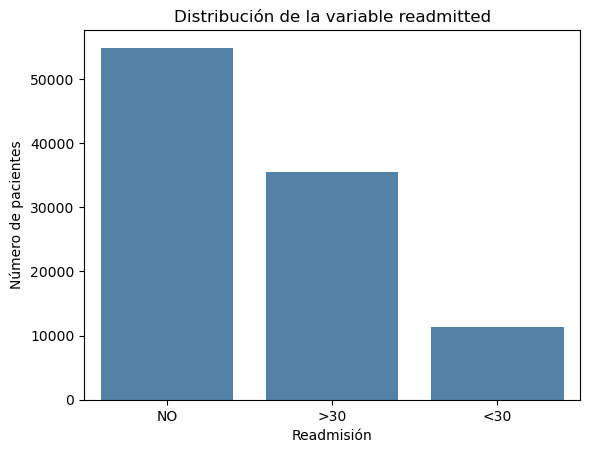

In [5]:
sns.countplot(data=df, x=target, color='steelblue')

plt.title('Distribución de la variable readmitted')
plt.xlabel('Readmisión')
plt.ylabel('Número de pacientes')
plt.show()

### Interpretación

| Clase | Pacientes | Porcentaje |
|---|---|---|
| `NO` | 54.864 | 53,91% |
| `>30` | 35.545 | 34,93% |
| `<30` | 11.357 | **11,16%** |

Existe un **desbalance claro** entre las clases, y afecta especialmente a `<30`, que es
justamente la clínicamente más importante.

Esto tiene dos consecuencias directas para la fase de modelado:

1. **El *accuracy* no servirá como métrica principal.** Un modelo que predijese siempre
   `NO` acertaría ya el 53,91% de las veces sin haber aprendido absolutamente nada, y
   fallaría en el 100% de los casos que de verdad importan.

2. **Habrá que tratar el desbalance explícitamente** y evaluar con métricas por clase
   (*precision*, *recall*, F1 y matriz de confusión), prestando atención especial al
   *recall* de `<30`: en un contexto clínico, no detectar a un paciente que va a
   reingresar es más costoso que dar una falsa alarma.

## 3 · Análisis de las variables numéricas

Una vez recuperados los tipos, el dataset contiene **8 variables cuantitativas reales**.
Todas ellas son recuentos o duraciones asociados al episodio hospitalario.

El objetivo de esta sección es conocer su distribución, su dispersión y la presencia de
valores extremos, para decidir cómo tratarlas más adelante.

### 3.1 · Distribuciones

El histograma agrupa los valores en intervalos y muestra cuántas observaciones caen en
cada uno. Permite ver de un vistazo dónde se concentran los datos y si la distribución
es simétrica o está sesgada. Las ocho variables se representan en una única figura de
2 × 4 subgráficas, que permite compararlas entre sí en lugar de recorrer ocho imágenes
sueltas.

> **Sobre `kde`:** no se utiliza estimación de densidad. Estas variables son recuentos
> discretos (`num_procedures` va de 0 a 6, `number_diagnoses` de 1 a 16) y una curva
> continua sugeriría valores intermedios que no existen.

In [6]:
columnas_numericas = df.select_dtypes(include=['int64', 'float64']).columns

print(f'Variables numéricas: {len(columnas_numericas)}')
print(list(columnas_numericas))

Variables numéricas: 8
['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']


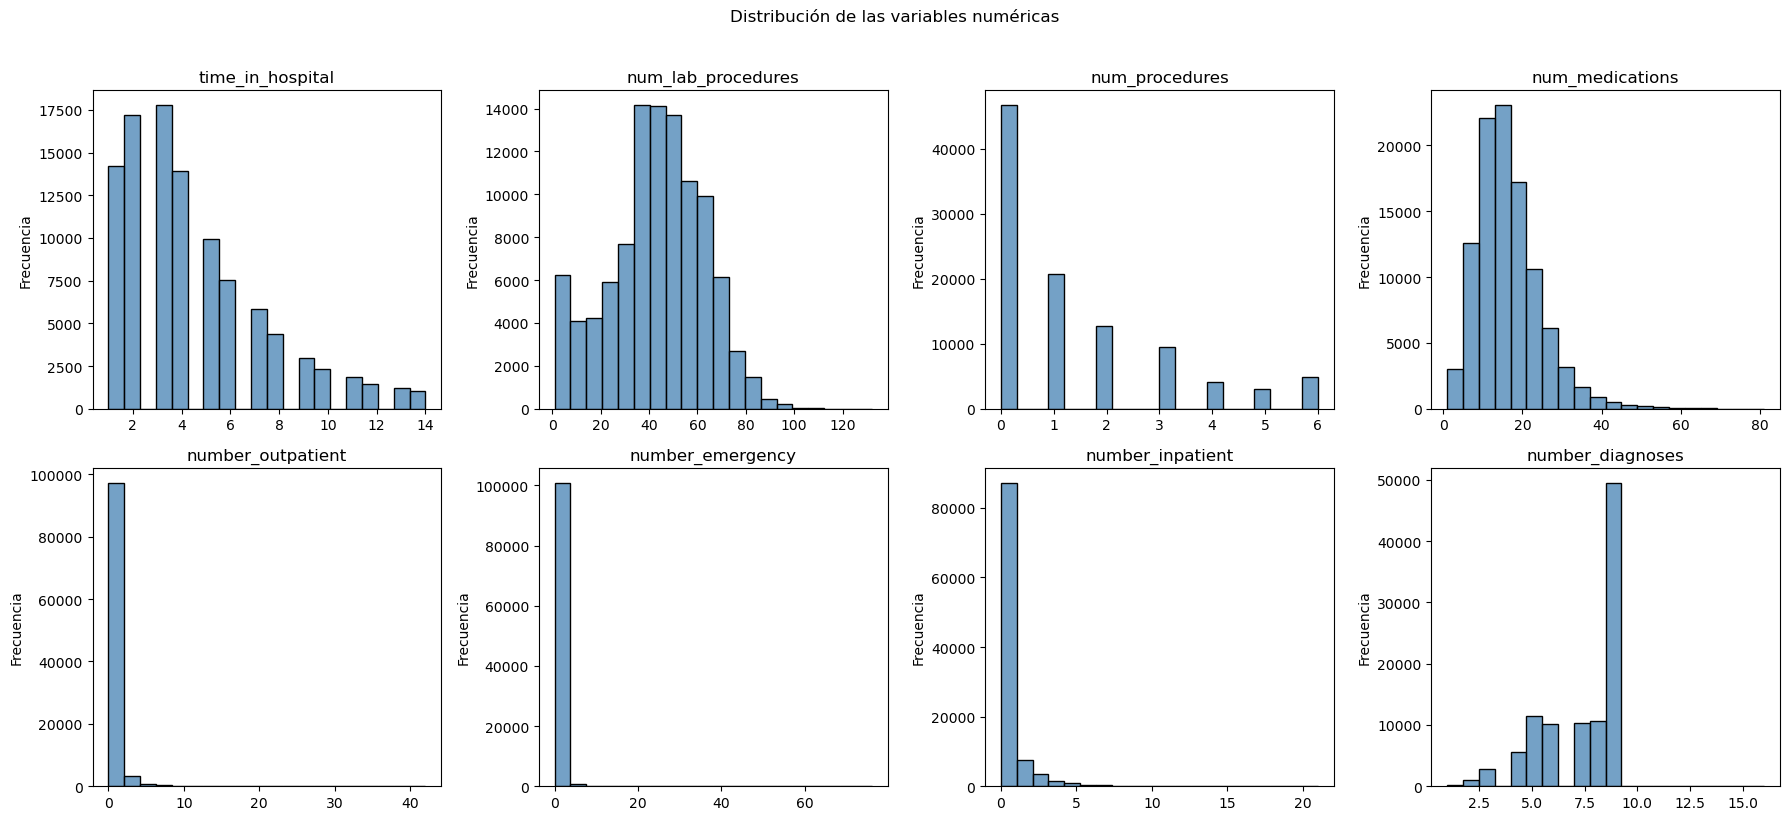

In [7]:
# plt.subplots(filas, columnas) devuelve la figura y una matriz de ejes: 2 x 4 = 8 huecos
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

# .flat recorre la matriz como una lista; zip empareja cada hueco con su variable
for ax, column in zip(axes.flat, columnas_numericas):
    sns.histplot(data=df, x=column, bins=20, ax=ax, color='steelblue')
    ax.set_title(column)
    ax.set_xlabel('')
    ax.set_ylabel('Frecuencia')

plt.suptitle('Distribución de las variables numéricas', y=1.02)
plt.tight_layout()
plt.show()

### 3.2 · Dispersión y valores extremos

El boxplot resume la mediana, el rango intercuartílico y los valores que quedan fuera
de los bigotes. Es complementario al histograma: donde el histograma muestra la forma,
el boxplot muestra la posición y la magnitud de los extremos. Misma cuadrícula de 2 × 4.

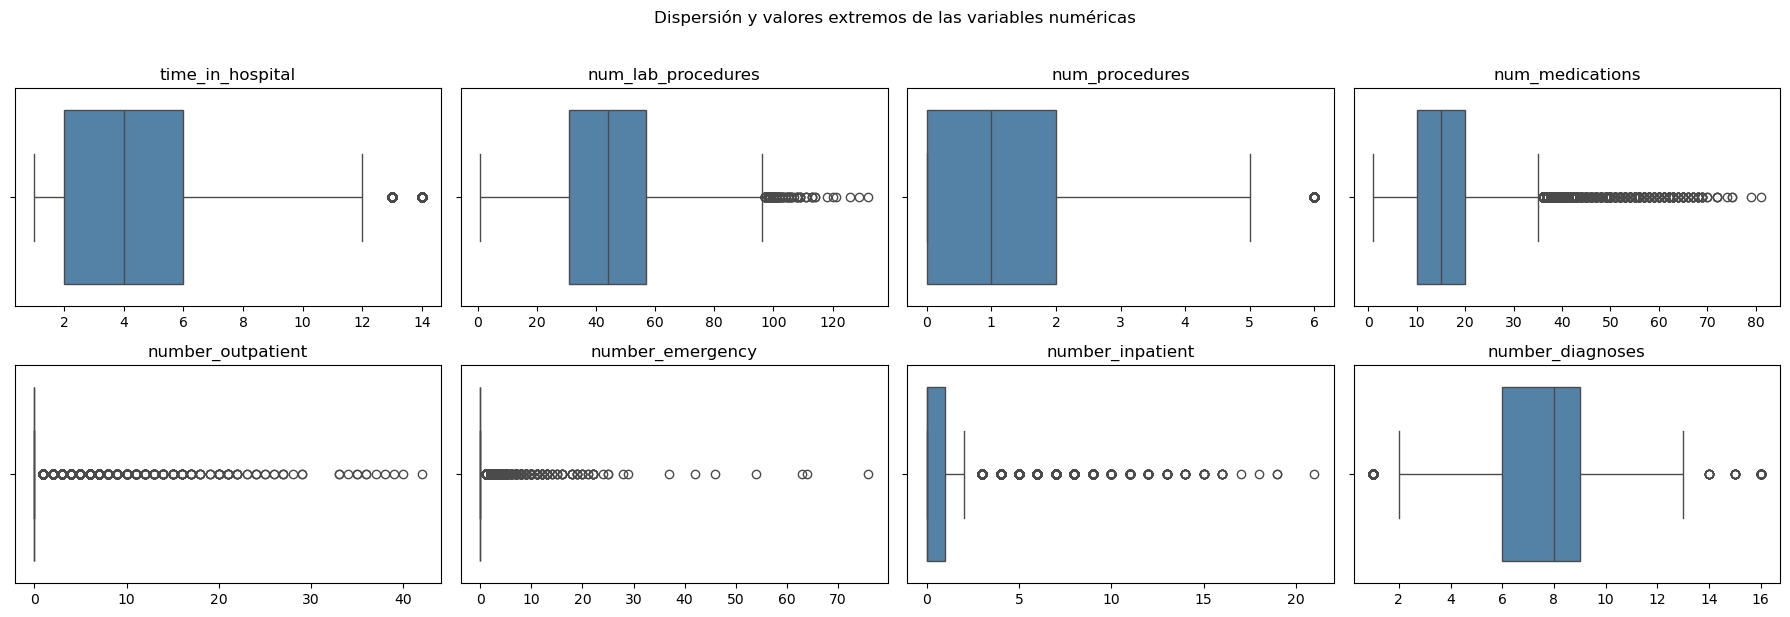

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 6))

for ax, column in zip(axes.flat, columnas_numericas):
    sns.boxplot(data=df, x=column, ax=ax, color='steelblue')
    ax.set_title(column)
    ax.set_xlabel('')

plt.suptitle('Dispersión y valores extremos de las variables numéricas', y=1.02)
plt.tight_layout()
plt.show()

### 3.3 · Conclusiones del análisis univariante

| Variable | Rango | Observación |
|---|---|---|
| `time_in_hospital` | 1 – 14 | Concentrada en valores bajos e intermedios, con una cola hacia estancias largas |
| `num_lab_procedures` | 1 – 132 | Dispersión considerable; es la variable con más recorrido |
| `num_procedures` | 0 – 6 | Rango muy pequeño y datos concentrados en unos pocos valores |
| `num_medications` | 1 – 81 | Dispersión considerable; hay pacientes polimedicados |
| `number_outpatient` | 0 – 42 | Fuerte sesgo a la derecha: la mayoría son 0 |
| `number_emergency` | 0 – 76 | Fuerte sesgo a la derecha: la mayoría son 0 |
| `number_inpatient` | 0 – 21 | Mismo patrón: muchos ceros y unos pocos pacientes con varios ingresos |
| `number_diagnoses` | 1 – 16 | Distribución más acotada y simétrica que el resto |

**Las tres variables de historial previo** (`number_outpatient`, `number_emergency`,
`number_inpatient`) comparten un patrón muy marcado: la mayoría de pacientes tienen 0 y
unos pocos acumulan valores muy altos.

### Decisión sobre los valores extremos

**No se eliminan.**

Un valor extremo desde el punto de vista estadístico no es necesariamente un error
clínico. Un paciente con 21 ingresos previos no es un fallo de registro: es un paciente
real con un patrón de uso intensivo del sistema sanitario y, con toda probabilidad, con
un riesgo de readmisión más alto que la media.

Eliminar esos casos equivaldría a borrar precisamente la señal que este proyecto intenta
detectar. Los valores extremos se conservan salvo que aparezca una razón concreta para
considerarlos erróneos, y ninguna de las variables presenta valores clínicamente
imposibles.

### 3.4 · Las variables numéricas frente a `readmitted`

Hasta aquí cada variable se ha descrito por separado. Ahora se comparan **entre las tres
clases** de la variable objetivo: si la distribución de una variable cambia según el
paciente reingrese o no, esa variable contiene información útil para predecirlo.

Se usa la **mediana** y no la media porque varias de estas variables tienen un sesgo
fuerte a la derecha, donde unos pocos valores muy altos distorsionarían la media.


In [9]:
# groupby(target) divide el DataFrame en tres grupos, uno por cada valor de readmitted.
# Después seleccionamos las columnas numéricas y pedimos la mediana de cada una.
# .T transpone la tabla: variables en las filas, clases en las columnas.

resumen_num = df.groupby(target)[columnas_numericas].median()
resumen_num.T

readmitted,<30,>30,NO
time_in_hospital,4.0,4.0,3.0
num_lab_procedures,45.0,45.0,44.0
num_procedures,1.0,1.0,1.0
num_medications,16.0,15.0,14.0
number_outpatient,0.0,0.0,0.0
number_emergency,0.0,0.0,0.0
number_inpatient,0.0,0.0,0.0
number_diagnoses,9.0,9.0,8.0


#### Interpretación de las medianas

Las diferencias entre clases son **pequeñas pero sistemáticas**:

| Variable | `<30` | `>30` | `NO` |
|---|---|---|---|
| `time_in_hospital` | 4 | 4 | 3 |
| `num_lab_procedures` | 45 | 45 | 44 |
| `num_procedures` | 1 | 1 | 1 |
| `num_medications` | 16 | 15 | 14 |
| `number_diagnoses` | 9 | 9 | 8 |

Ninguna variable separa las clases de forma marcada. Sin embargo, en todas aquellas donde
existe diferencia, **la dirección es siempre la misma**:

`<30` ≥ `>30` ≥ `NO`

Los pacientes readmitidos antes de 30 días presentan de forma consistente estancias más
largas, más medicaciones, más diagnósticos y más pruebas de laboratorio. Que el patrón se
repita en cinco variables distintas sugiere un perfil clínico coherente: **el paciente que
reingresa pronto es el paciente más complejo**. Es una señal débil individualmente, pero
combinable por un modelo.

#### Limitación detectada: la mediana no sirve para las variables de historial previo

Las tres variables de visitas previas devuelven **0 en las tres clases**:

| Variable | `<30` | `>30` | `NO` |
|---|---|---|---|
| `number_outpatient` | 0 | 0 | 0 |
| `number_emergency` | 0 | 0 | 0 |
| `number_inpatient` | 0 | 0 | 0 |

Esto no significa que no haya diferencias, sino que **la mediana no puede detectarlas aquí**.
Como se vio en el análisis univariante, más del 50% de los pacientes tienen 0 visitas previas
en cualquiera de los tres grupos, de modo que el valor central es 0 con independencia de lo
que ocurra en el resto de la distribución.

La mediana es robusta frente a los valores extremos, y en estas variables **toda la
información está precisamente en esos valores extremos**: el paciente relevante es el que
acumula varios ingresos, y la mediana lo ignora.

La elección de la mediana sigue siendo la correcta para `time_in_hospital` o
`num_medications`, donde el sesgo distorsionaría la media. La conclusión es que **una única
medida no describe adecuadamente las ocho variables**.

Para las tres variables de historial se emplean por tanto dos medidas complementarias:

- **La media**, que sí se ve afectada por los valores altos y, en este caso, eso es
  deseable: interesa que los pacientes con muchos ingresos previos pesen en el resultado.
- **El porcentaje de pacientes con al menos una visita previa**, de interpretación clínica
  directa.


In [10]:
# 1) MEDIA de las 8 variables numéricas, separada por clase de readmitted.
#    Comparada con la tabla de medianas: donde media y mediana difieran mucho,
#    es señal de que la cola de la distribución está aportando información.
print('MEDIA POR CLASE')
print(df.groupby(target)[columnas_numericas].mean().T.round(2))


# 2) PORCENTAJE de pacientes con al menos 1 visita previa, por clase.
#    Solo para las tres variables de historial, que son las que tienen masa de ceros.
#    (df[historial] > 0) es una tabla de True/False; la media de una columna booleana
#    es la proporción de True, así que .mean() da directamente el % de pacientes con >= 1.
historial = ['number_outpatient', 'number_emergency', 'number_inpatient']

print('\nPORCENTAJE DE PACIENTES CON AL MENOS 1 VISITA PREVIA, POR CLASE')
print(((df[historial] > 0).groupby(df[target]).mean() * 100).T.round(2))

MEDIA POR CLASE
readmitted            <30    >30     NO
time_in_hospital     4.77   4.50   4.25
num_lab_procedures  44.23  43.84  42.38
num_procedures       1.28   1.25   1.41
num_medications     16.90  16.28  15.67
number_outpatient    0.44   0.50   0.27
number_emergency     0.36   0.28   0.11
number_inpatient     1.22   0.84   0.38
number_diagnoses     7.69   7.65   7.22

PORCENTAJE DE PACIENTES CON AL MENOS 1 VISITA PREVIA, POR CLASE
readmitted           <30    >30     NO
number_outpatient  20.08  21.12  12.67
number_emergency   16.64  15.02   7.57
number_inpatient   49.76  42.81  24.18


### 3.5 · Conclusiones del análisis numérico frente a la variable objetivo

#### Resultados

Ordenando las ocho variables por el cociente entre la media de la clase `<30` y la de la
clase `NO`:

| Variable | `<30` | `>30` | `NO` | `<30` ÷ `NO` |
|---|---|---|---|---|
| `number_emergency` | 0,36 | 0,28 | 0,11 | **3,3×** |
| `number_inpatient` | 1,22 | 0,84 | 0,38 | **3,2×** |
| `number_outpatient` | 0,44 | 0,50 | 0,27 | 1,6× |
| `time_in_hospital` | 4,77 | 4,50 | 4,25 | 1,12× |
| `num_medications` | 16,90 | 16,28 | 15,67 | 1,08× |
| `number_diagnoses` | 7,69 | 7,65 | 7,22 | 1,07× |
| `num_lab_procedures` | 44,23 | 43,84 | 42,38 | 1,04× |
| `num_procedures` | 1,28 | 1,25 | 1,41 | 0,91× |

#### 1. El historial asistencial previo es lo que más discrimina

Las tres variables de historial triplican o casi duplican los valores de la clase `NO`,
mientras que el resto se mueve entre el 4% y el 12% de diferencia. La intuición clínica de
partida —que el uso previo del sistema sanitario anticipa el reingreso— se confirma con holgura.

#### 2. `number_inpatient` es la variable más útil del bloque

`number_emergency` presenta un cociente ligeramente superior (3,3× frente a 3,2×), pero el
cociente por sí solo no basta: hay que considerar **a cuántos pacientes afecta**.

| Variable | Cociente | % de pacientes `<30` con al menos 1 |
|---|---|---|
| `number_emergency` | 3,3× | 16,6% |
| `number_inpatient` | 3,2× | **49,8%** |

`number_emergency` discrimina bien, pero únicamente sobre el 17% de los pacientes; para el
resto vale 0 y no aporta información. `number_inpatient` discrimina igual de bien y cubre a
la mitad de la muestra, por lo que es la candidata más sólida del bloque numérico.

En términos absolutos: **el 49,76% de los pacientes readmitidos antes de 30 días había
ingresado previamente, frente al 24,18% de los que no fueron readmitidos.** Conviene
mantener la dirección de la afirmación: el dato describe qué proporción de cada clase tenía
antecedentes, no qué proporción de los pacientes con antecedentes acaba reingresando.

La lectura clínica es coherente: un historial de ingresos identifica a un paciente con
patología inestable o mal controlada, y ese es el perfil que vuelve.

#### 3. Dos comportamientos que rompen el patrón general

**`num_procedures`** es la única variable en la que la clase `NO` presenta el valor más alto
(1,41 frente a 1,28 y 1,25). Una interpretación plausible —no demostrada aquí— es que un
procedimiento suele corresponder a una intervención resolutiva, mientras que el paciente con
muchos diagnósticos y mucha medicación pero sin procedimientos responde al perfil crónico
descompensado, que se estabiliza y reingresa. Se registra como observación.

**`number_outpatient`** presenta un valor superior en `>30` que en `<30`, tanto en la media
(0,50 frente a 0,44) como en la proporción de pacientes con antecedentes (21,12% frente a
20,08%). Que dos medidas independientes coincidan indica que la inversión no es un
artefacto. Sugiere que las consultas externas, al reflejar seguimiento ambulatorio y no un
evento agudo, se asocian a reingresos más tardíos.

#### 4. El resto de variables aportan una señal débil pero consistente

`time_in_hospital`, `num_medications` y `number_diagnoses` muestran diferencias pequeñas
(4-12%), pero **siempre en la misma dirección**: `<30` ≥ `>30` ≥ `NO`. Que el patrón se
repita en variables independientes apunta a un perfil clínico coherente —el paciente que
reingresa pronto es el paciente más complejo— y son señales que un modelo puede combinar
aunque por separado valgan poco.

`num_lab_procedures` presenta una diferencia del 4% y no parece informativa por sí sola.

#### 5. Lección metodológica

La mediana devolvía `0` en las tres variables de historial y sugería ausencia de
diferencias. La media y la proporción de pacientes con antecedentes revelaron diferencias de
hasta 3,3×. **La conclusión no es que la mediana fuese una mala elección, sino que ninguna
medida única describe correctamente ocho variables con distribuciones distintas.** En
variables con una concentración elevada de ceros, toda la información reside en la cola, y
un estadístico robusto frente a los valores extremos es precisamente el que no puede verla.

#### Implicaciones para el modelado

| Categoría | Variables |
|---|---|
| Candidatas sólidas | `number_inpatient`, `number_emergency`, `number_outpatient` |
| Señal débil pero consistente | `time_in_hospital`, `num_medications`, `number_diagnoses` |
| A vigilar por comportamiento inverso | `num_procedures` |
| Escasa capacidad discriminante aislada | `num_lab_procedures` |

Ninguna variable numérica separa las clases de forma marcada. Esto es esperable: la
readmisión depende en gran medida de factores que el dataset no recoge —apoyo familiar,
adherencia al tratamiento, acceso a atención primaria, nivel socioeconómico—. El objetivo del
modelo no será alcanzar una separación perfecta, sino combinar señales débiles para estimar
un riesgo relativo.

---

Con esto queda cerrado el análisis de las variables numéricas. La siguiente sección aborda
las 27 variables categóricas, que constituyen la mayor parte del dataset.


## 4 · Análisis de las variables categóricas

De las 35 variables del dataset limpio, **27 son categóricas**. Constituyen por tanto la
mayor parte de la información disponible, e incluyen tanto variables demográficas (`race`,
`gender`, `age`) como administrativas (`admission_type_id`, `payer_code`,
`medical_specialty`), clínicas (`diag_1`, `diag_2`, `diag_3`, `max_glu_serum`, `A1Cresult`)
y de tratamiento (los distintos fármacos, `change`, `diabetesMed`).

El análisis sigue el mismo recorrido aplicado a las variables numéricas: primero se describen
por separado y después se cruzan con la variable objetivo.

### 4.1 · Cardinalidad y categoría dominante

Con una variable categórica no es posible representar un histograma ni un boxplot, de modo
que la primera pregunta no es cómo se distribuye, sino **qué forma tiene**. Tres datos la
resumen:

| Dato | Información que aporta |
|---|---|
| **Cardinalidad** — número de categorías distintas | Determina si la variable puede representarse gráficamente y cómo deberá codificarse para el modelo |
| **Categoría dominante** | Identifica el valor más frecuente |
| **Porcentaje que representa la categoría dominante** | Detecta variables con escasa variabilidad, en las que casi todos los pacientes comparten el mismo valor |

Estos tres números condicionan decisiones posteriores:

- Una **cardinalidad baja** (2-10 categorías) permite representar y codificar la variable sin
  dificultad.
- Una **cardinalidad elevada**, como la de los códigos de diagnóstico, impide tanto la
  representación directa como la codificación One-Hot, que generaría cientos de columnas
  nuevas. Estas variables requerirán agrupación previa.
- El **porcentaje dominante** informa sobre el grado de equilibrio de la variable.

Conviene precisar el alcance de este análisis. La detección de variables **casi constantes**
ya se realizó durante la limpieza (notebook 02), aplicando un umbral del 99% sobre todas las
columnas: se eliminaron diez fármacos con una única categoría dominante y muy pocos casos
informativos, y se conservaron de forma razonada `nateglinide`, `acarbose` y
`glyburide-metformin`. Ese cribado no se repite aquí.

Lo que esta tabla aporta es distinto:

1. **La cardinalidad de las 27 variables categóricas del dataset limpio**, que aún no se
   había cuantificado y que determina la estrategia de codificación para el modelo.
2. **Las variables situadas entre el 90% y el 99% de dominancia**, que quedaron por debajo
   del umbral aplicado en la limpieza y que, sin ser casi constantes, presentan un
   desequilibrio suficiente como para tenerlo en cuenta al interpretarlas.
3. **El criterio para seleccionar qué variables merecen representación gráfica propia** en el
   apartado siguiente, evitando generar 27 figuras indiscriminadamente.


In [11]:
columnas_categoricas = df.select_dtypes(include=['object', 'category']).columns
print(f'Variables categóricas: {len(columnas_categoricas)}')

filas = []

for col in columnas_categoricas:
    conteo = df[col].value_counts(dropna=False)

    filas.append({
        'Variable':            col,
        'Nº de categorías':    df[col].nunique(),
        'Categoría dominante': conteo.index[0],
        '% dominante':         conteo.iloc[0] / len(df) * 100,
        'Nulos':               df[col].isna().sum(),
    })

resumen_cat = (pd.DataFrame(filas)
                 .sort_values('% dominante', ascending=False)
                 .reset_index(drop=True)
                 .round(2))
resumen_cat

Variables categóricas: 27


,Variable,Nº de categorías,Categoría dominante,% dominante,Nulos
0,acarbose,4,No,99.70,0
1,nateglinide,4,No,99.31,0
2,glyburide-metformin,4,No,99.31,0
3,repaglinide,4,No,98.49,0
4,glimepiride,4,No,94.90,0
5,max_glu_serum,4,Not_Measured,94.75,0
6,rosiglitazone,4,No,93.75,0
7,pioglitazone,4,No,92.80,0
8,glyburide,4,No,89.53,0
9,glipizide,4,No,87.53,0


#### Resultados: tres grupos por cardinalidad

| Grupo | Variables | Implicación |
|---|---|---|
| **Baja** (2-10 categorías) | Los 11 fármacos, `max_glu_serum`, `A1Cresult`, `change`, `gender`, `diabetesMed`, `race`, `age`, `admission_type_id` | Representables y codificables sin dificultad |
| **Media** (17-26) | `admission_source_id` (17), `payer_code` (18), `discharge_disposition_id` (26) | Representables con cuidado; codificación One-Hot asumible |
| **Alta** (73-789) | `medical_specialty` (73), `diag_1` (716), `diag_2` (748), `diag_3` (789) | **Requieren agrupación previa** |

Dos precisiones sobre la tabla:

- `readmitted` aparece en el listado porque es una variable categórica, pero es la **variable
  objetivo**, no una predictora. Deberá excluirse al construir el conjunto de predictores.
- `medical_specialty`, con **73 categorías**, se incorpora al grupo de variables que exigen
  agrupación. Era un problema previsto para los códigos de diagnóstico, pero no para esta
  variable: no puede representarse gráficamente de forma legible ni codificarse en 73 columnas
  independientes.

#### Variables entre el 90% y el 99% de dominancia

Estas cinco variables quedaron por debajo del umbral del 99% aplicado en la limpieza y, por
tanto, no habían sido revisadas:

| Variable | % dominante | Casos informativos |
|---|---|---|
| `repaglinide` | 98,49% | 1.539 |
| `glimepiride` | 94,90% | 5.191 |
| `max_glu_serum` | 94,75% | 5.346 |
| `rosiglitazone` | 93,75% | 6.365 |
| `pioglitazone` | 92,80% | 7.328 |

No se elimina ninguna: todas cuentan con miles de observaciones informativas, no con decenas.
Sí conviene tenerlo presente al cruzarlas con la variable objetivo, porque se compararán
grupos de tamaño muy desigual y el margen para extraer conclusiones sólidas será limitado.

#### Las variables de medicación como bloque

Once de las 27 variables categóricas corresponden a fármacos, y **todas presentan `No` como
categoría dominante**, con porcentajes entre el 80% y el 99,7%:

```
acarbose 99,70 · nateglinide 99,31 · glyburide-metformin 99,31 · repaglinide 98,49
glimepiride 94,90 · rosiglitazone 93,75 · pioglitazone 92,80 · glyburide 89,53
glipizide 87,53 · metformin 80,36 · insulin 46,56
```

`insulin` es la excepción clara: con un 46,56% de dominancia es la única variable de
medicación razonablemente equilibrada (30.849 pacientes en `Steady`, 12.218 en `Down` y
11.316 en `Up`). Dado que la insulina corresponde al tratamiento de los casos de mayor
severidad, es una candidata prometedora. `metformin` (80,36%) la sigue a distancia; el resto
son variables de nicho.

#### Las pruebas de laboratorio

```
max_glu_serum   94,75% Not_Measured  →   5.346 pacientes con resultado
A1Cresult       83,28% Not_Measured  →  17.018 pacientes con resultado
```

La glucosa en suero apenas se determina. La hemoglobina glicosilada se mide en tres veces más
pacientes, lo que la hace más aprovechable.

`A1Cresult` merece atención específica: **el hecho de que la prueba se solicite o no
constituye en sí mismo un indicador del seguimiento del paciente**, y esa distinción es
precisamente la que se preservó en la limpieza mediante la categoría `Not_Measured` en lugar
de imputar un valor.

#### Los códigos de diagnóstico

```
diag_1   716 categorías   dominante 250 (11,35%)       21 nulos
diag_2   748 categorías   dominante 276 ( 6,63%)      358 nulos
diag_3   789 categorías   dominante 428 ( 6,74%)    1.423 nulos
```

La categoría más frecuente de `diag_1` es el código **250 (diabetes mellitus)** y aun así
cubre solo el 11,35% de los registros. La información está extremadamente repartida, lo que
confirma la necesidad de agrupar estos códigos antes de cualquier representación o
codificación.

#### `discharge_disposition_id` y los pacientes fallecidos

Con 26 categorías y un 59,19% concentrado en el código `1` (alta a domicilio), esta variable
contiene entre sus categorías restantes los códigos **11, 19, 20 y 21, correspondientes a
pacientes fallecidos durante el ingreso**. Es la variable en la que se resolverá esa cuestión
pendiente, al cruzarla con la variable objetivo en el apartado siguiente.

#### Decisiones derivadas de este análisis

| Decisión | Variables |
|---|---|
| Representables y cruzables directamente | Las de cardinalidad baja y media |
| Requieren agrupación previa | `diag_1`, `diag_2`, `diag_3`, `medical_specialty` |
| Candidatas prometedoras a vigilar | `insulin`, `A1Cresult`, `discharge_disposition_id`, `age` |
| Margen limitado para conclusiones | Los cuatro fármacos por encima del 98% |

El apartado siguiente aborda la representación gráfica de las variables seleccionadas, y el
posterior su cruce con la variable objetivo.

### 4.2 · Representación gráfica de las variables categóricas

No se representan las 27 variables. Una gráfica se justifica cuando muestra algo que la tabla
anterior no muestra; en caso contrario únicamente añade ruido visual. Se aplican por tanto los
siguientes criterios de exclusión:

| Bloque excluido | Variables | Motivo |
|---|---|---|
| Alta cardinalidad | `diag_1`, `diag_2`, `diag_3`, `medical_specialty` | Entre 73 y 789 categorías: no admiten representación legible. Pendientes de agrupación |
| Dominancia superior al 90% | `acarbose`, `nateglinide`, `glyburide-metformin`, `repaglinide`, `glimepiride`, `rosiglitazone`, `pioglitazone`, `max_glu_serum` | La figura mostraría una única barra dominante y el resto inapreciables. Los recuentos exactos ya constan en el apartado 4.1 |
| Variable objetivo | `readmitted` | Representada en la sección 2 |

Las 14 variables restantes se representan en dos formatos distintos según su cardinalidad:

- **Cardinalidad baja (2-10 categorías)** — `gender`, `race`, `age`, `admission_type_id`,
  `A1Cresult`, `insulin`, `metformin`, `glipizide`, `glyburide`, `change`, `diabetesMed`.
  Se agrupan en una única figura con múltiples subgráficas, lo que permite compararlas de un
  vistazo en lugar de recorrer once imágenes independientes.

- **Cardinalidad media (17-26 categorías)** — `admission_source_id`, `payer_code`,
  `discharge_disposition_id`. Se representan por separado y en **orientación horizontal**: con
  más de quince categorías las etiquetas del eje X se solapan, mientras que en horizontal caen
  una debajo de otra y resultan legibles. Se ordenan por frecuencia descendente.

**Orden de las categorías.** Por defecto, `countplot` representa las categorías en el orden en
que aparecen en el dataset, que es arbitrario y no aporta información. Se impone por tanto un
orden explícito según la naturaleza de cada variable:

- Las variables con **progresión natural** —`age`, `admission_type_id`, `A1Cresult` y las de
  medicación— se ordenan siguiendo esa progresión: de menor a mayor edad, de resultado normal a
  peor control glucémico y de ausencia de tratamiento a dosis incrementada. De este modo la
  figura muestra una secuencia interpretable y no un conjunto de frecuencias sueltas.
- Las variables **nominales** —`gender`, `race`, `change`, `diabetesMed`—, que carecen de orden
  intrínseco, se ordenan por frecuencia descendente.

> El apartado 5.3 mostrará que, en el caso de `insulin`, el orden `No → Down → Steady → Up` no
> corresponde a una progresión real: la variable no es ordinal. Se mantiene aquí tal como se
> planteó, porque documentar por qué se corrigió forma parte del análisis.

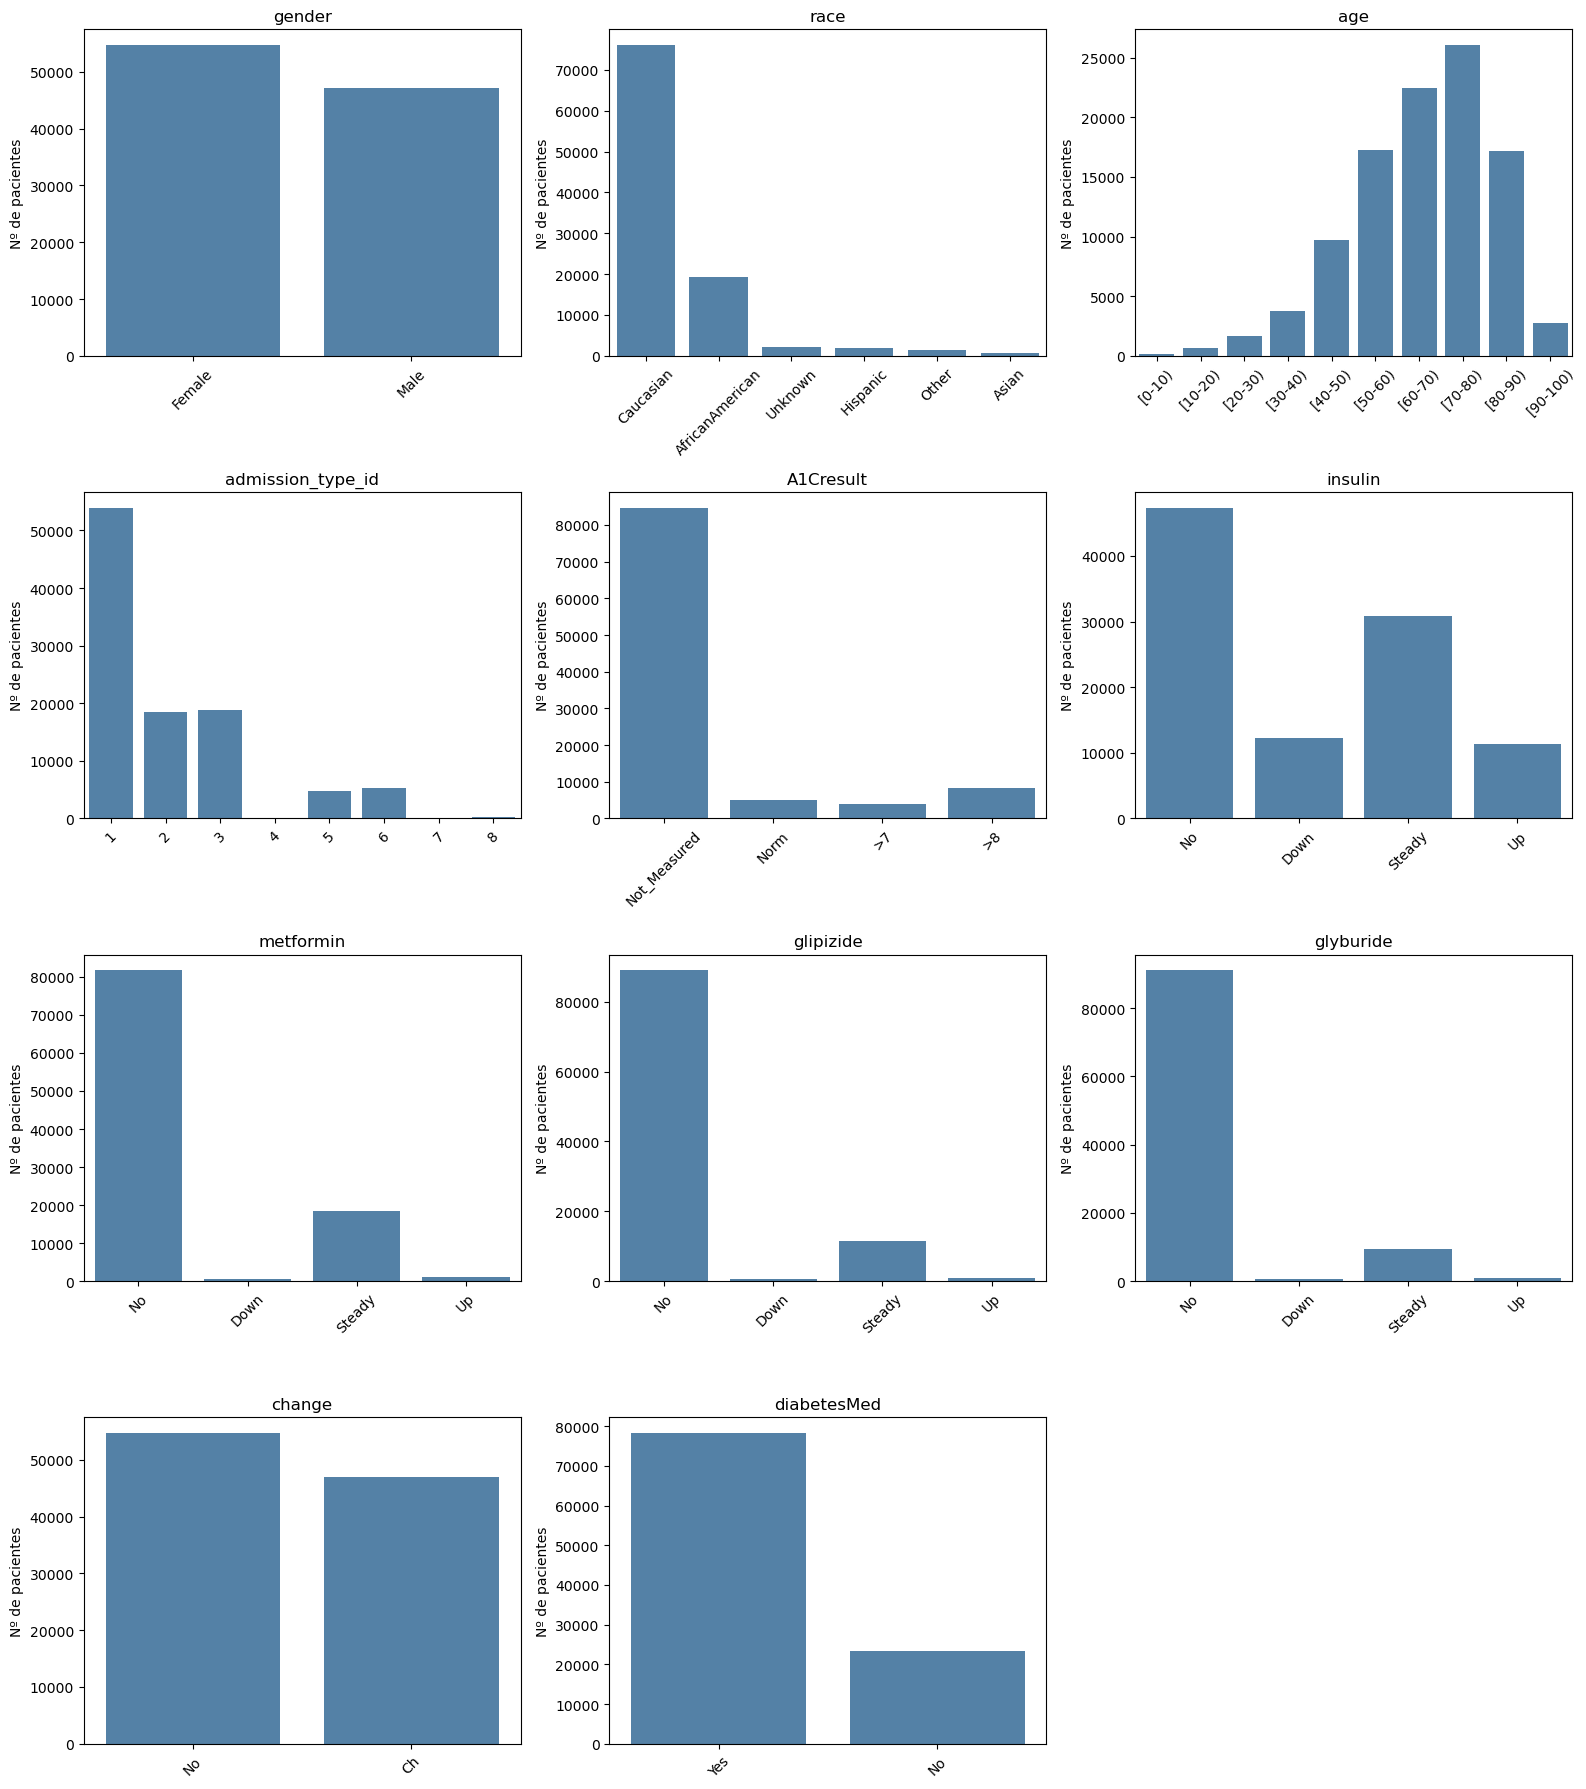

In [12]:
# Las 11 variables de cardinalidad baja seleccionadas
cat_bajas = ['gender', 'race', 'age', 'admission_type_id', 'A1Cresult', 'insulin',
             'metformin', 'glipizide', 'glyburide', 'change', 'diabetesMed']

# Orden explícito para las variables que tienen una progresión natural.
# Sin esto, countplot las dibuja en el orden en que aparecen en el dataset, que es arbitrario.
ordenes = {
    'age':               sorted(df['age'].unique()),                # de menor a mayor edad
    'admission_type_id': sorted(df['admission_type_id'].unique()),  # códigos 1 a 8
    'A1Cresult':         ['Not_Measured', 'Norm', '>7', '>8'],      # de normal a peor control
    'insulin':           ['No', 'Down', 'Steady', 'Up'],            # de nada a dosis aumentada
    'metformin':         ['No', 'Down', 'Steady', 'Up'],
    'glipizide':         ['No', 'Down', 'Steady', 'Up'],
    'glyburide':         ['No', 'Down', 'Steady', 'Up'],
}

# plt.subplots(filas, columnas) devuelve la figura y una matriz de ejes (los huecos).
# 4 x 3 = 12 huecos para 11 variables.
fig, axes = plt.subplots(4, 3, figsize=(16, 18))

# .flat recorre la matriz de ejes como una lista; zip empareja cada hueco con su variable.
for ax, col in zip(axes.flat, cat_bajas):
    # .get(col, alternativa): si la variable no tiene orden fijado, se ordena por frecuencia
    orden = ordenes.get(col, df[col].value_counts().index)

    sns.countplot(data=df, x=col, ax=ax, color='steelblue', order=orden)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('Nº de pacientes')
    ax.tick_params(axis='x', rotation=45)

# Quedan 12 huecos y 11 variables: ocultamos el último para que no aparezca vacío
axes.flat[11].set_visible(False)

plt.tight_layout()
plt.show()

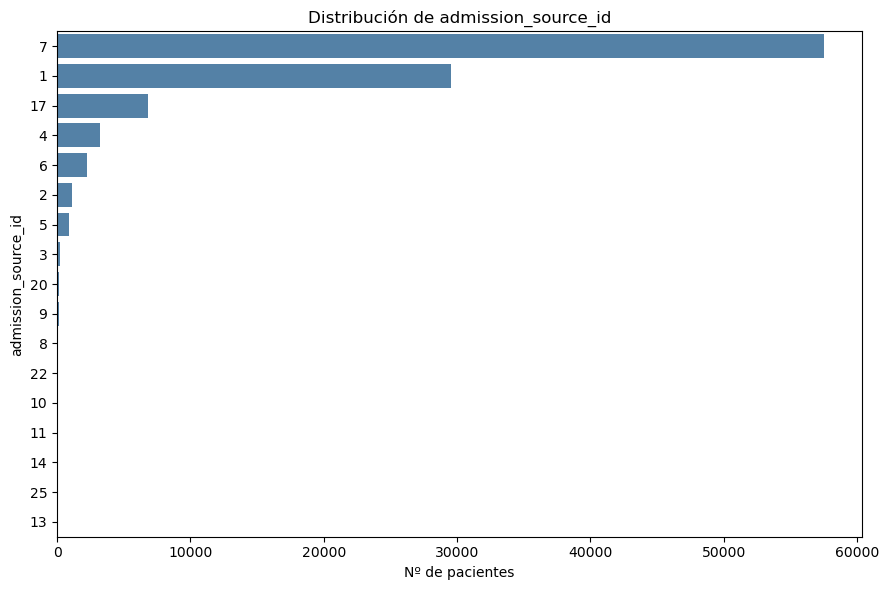

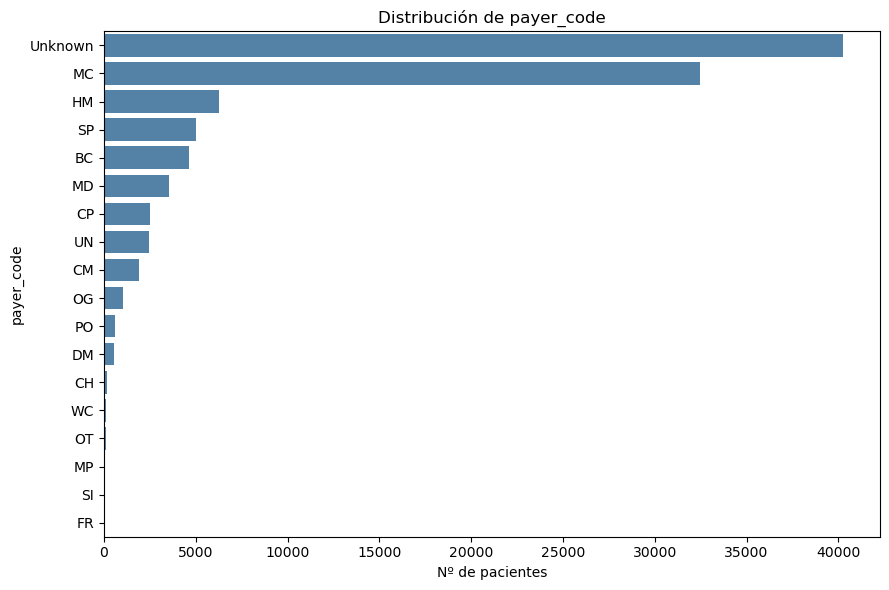

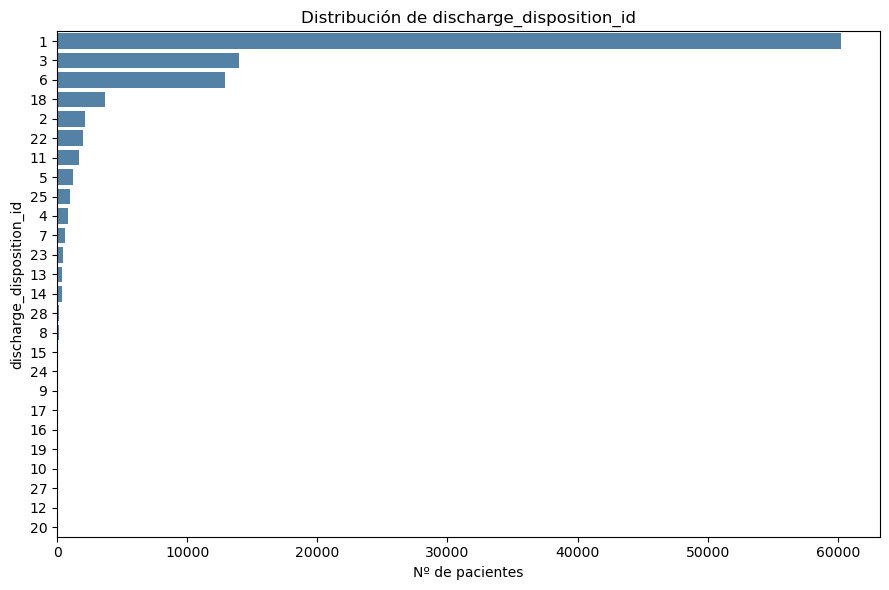

In [13]:
# Las 3 variables de cardinalidad media: 17, 18 y 26 categorías
cat_medias = ['admission_source_id', 'payer_code', 'discharge_disposition_id']

for col in cat_medias:
    plt.figure(figsize=(9, 6))

    # y=col en lugar de x=col -> barras horizontales, etiquetas legibles.
    # order = categorías ordenadas por frecuencia descendente (son nominales,
    # no tienen progresión natural). value_counts().index las devuelve ya ordenadas
    # y cubre TODAS las categorías, así que ninguna queda silenciada.
    sns.countplot(data=df, y=col, color='steelblue',
                  order=df[col].value_counts().index)

    plt.title(f'Distribución de {col}')
    plt.xlabel('Nº de pacientes')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

## 5 · Las variables categóricas frente a `readmitted`

Las secciones anteriores describían cada variable por separado. A partir de aquí el objetivo cambia:
ya no interesa cómo se reparten los pacientes dentro de una variable, sino **si esa variable guarda
relación con la readmisión**.

**Con variables categóricas no se comparan recuentos, se comparan proporciones.** Es el error más
frecuente de este tipo de análisis. En `race` hay 76.099 pacientes caucásicos y 641 asiáticos: por
fuerza habrá muchos más caucásicos readmitidos, y eso no informa de nada. La pregunta correcta no es
cuántos pacientes de cada categoría reingresan, sino **qué porcentaje de cada categoría reingresa**.

La herramienta es `pd.crosstab` con `normalize='index'`, que convierte cada fila en un reparto
porcentual: de todos los pacientes de una categoría, qué porcentaje cae en `<30`, en `>30` y en `NO`.
Cada fila suma 100.

**La referencia con la que se compara** es la distribución global de la variable objetivo,
establecida en la sección 2:

| Clase | % global |
|---|---|
| `NO` | 53,91 |
| `>30` | 34,93 |
| `<30` | **11,16** |

Una categoría resulta informativa cuando **se desvía** de estas cifras. Si en todas las categorías de
una variable el reparto se parece al global, esa variable no distingue a los pacientes readmitidos de
los que no lo son, por muy desigual que sea su distribución interna.

**Una cautela imprescindible: el porcentaje oculta el tamaño.** Una categoría con 10 pacientes de los
que 3 reingresan da un 30%, muy por encima del 11,16% global, y sin embargo es ruido: basta un
paciente para moverlo diez puntos. `admission_type_id` tiene precisamente dos categorías de 21 y 10
pacientes. Por eso todas las tablas de esta sección incluyen una columna `N` con el número de
pacientes de cada categoría: **un porcentaje sin su N no es interpretable**.

Aquí es también donde debe aparecer la evidencia sobre los **pacientes fallecidos**
(`discharge_disposition_id` 11, 19, 20 y 21), que por definición no pueden ser readmitidos y deberían
mostrar un 100% en la clase `NO`.

### 5.1 · La tabla de proporciones: `age`

La misma tabla va a construirse para catorce variables, de modo que se define una vez como función en
lugar de repetir el mismo bloque catorce veces. Se estrena con `age`, que es la candidata más sólida
del apartado 4.1: es **ordinal**, así que sus categorías tienen un orden natural y permiten buscar
algo más exigente que una diferencia suelta, una **tendencia** a lo largo de los tramos de edad.

In [14]:
def tabla_readmision(col):
    """Reparto porcentual de readmitted dentro de cada categoría de col, con su N."""

    # normalize='index' reparte sobre el total de cada FILA: cada fila suma 100.
    # Sin normalize, crosstab devolvería recuentos, que es justo lo que no queremos comparar.
    tabla = pd.crosstab(df[col], df[target], normalize='index') * 100

    # Nº de pacientes de cada categoría: un porcentaje sin su N no es interpretable.
    # pandas empareja value_counts() con la tabla por el nombre de la categoría.
    tabla['N'] = df[col].value_counts()

    return tabla.round(2)


tabla_readmision('age')

readmitted,<30,>30,NO,N
age,,,,
[0-10),1.86,16.15,81.99,161
[10-20),5.79,32.42,61.79,691
[20-30),14.24,30.78,54.98,1657
[30-40),11.23,31.44,57.32,3775
[40-50),10.60,33.85,55.55,9685
[50-60),9.67,34.29,56.04,17256
[60-70),11.13,35.12,53.75,22483
[70-80),11.77,36.35,51.88,26068
[80-90),12.08,36.19,51.73,17197


#### Interpretación: una asociación real, pero débil

La primera lectura de la tabla invita a una conclusión rotunda: la readmisión aumenta con la edad,
porque la clase `NO` cae del 81,99% en `[0-10)` al 51,73% en `[80-90)`. La dirección es correcta,
pero la magnitud queda muy exagerada. Tres matices lo explican, y los tres son errores de lectura
frecuentes en este tipo de tabla.

**1 · El porcentaje no dice nada sin su N.** De los treinta puntos que cae `NO`, veintiséis se
consumen en los tres primeros tramos de edad, que suman **2.509 pacientes: el 2,5% del dataset**. En
el rango donde se concentra el 92% de los pacientes —de `[40-50)` a `[80-90)`— la caída es de
55,55% a 51,73%: **3,8 puntos**. Es el mismo criterio aplicado en la sección 3.5 con
`number_emergency`: un efecto grande sobre muy pocos casos pesa menos que uno moderado sobre la
mitad de la muestra.

**2 · La tendencia aparece en `>30`, no en `<30`.** La clase clínicamente relevante apenas se mueve:
entre los tramos con N suficiente recorre del 9,67% al 12,08%, en torno al 11,16% global, y con un
descenso intercalado en `[50-60)`. El cociente entre extremos es de 1,25×, frente al 3,2× que
alcanzaba `number_inpatient`. La progresión limpia es la de `>30` (31,44% → 36,35%). Lo que la edad
anticipa, por tanto, es el **reingreso tardío**, no el precoz.

**3 · La progresión no es monótona: se rompe dos veces.** El tramo `[20-30)` presenta el `<30` más
alto de toda la tabla (14,24% sobre 1.657 pacientes, de modo que no es ruido), y `[90-100)` invierte
la tendencia: `>30` cae al 28,93% y `NO` sube al 59,97%.

**Una hipótesis sobre el último tramo.** Ese giro en `[90-100)` es sospechoso de ser un artefacto y
no un hallazgo clínico. Los pacientes que fallecen durante el ingreso figuran en el dataset como
`readmitted = NO`, y la mortalidad hospitalaria se concentra precisamente en los mayores de noventa
años: parte de ese 59,97% no significaría "no reingresó" sino "no pudo reingresar". La hipótesis es
contrastable en el apartado 5.5, al cruzar `discharge_disposition_id` con la variable objetivo: si al
descontar los códigos de fallecimiento el tramo se recoloca en la tendencia general, queda
demostrada.

**Conclusión.** `age` mantiene una asociación real y coherente en su dirección, pero **débil en
magnitud y concentrada en la clase `>30`**. No es una variable descartable —la señal existe y cubre
a todos los pacientes—, pero por sí sola no sostendrá una predicción. Se conserva como predictora
secundaria.

Queda además establecido el método de lectura para el resto de la sección: **leer primero la columna
`N`, después comparar la columna `<30` con el 11,16% global**, y desconfiar de cualquier categoría
cuyo porcentaje descanse sobre unos pocos cientos de pacientes.

### 5.2 · Las variables demográficas y administrativas

Las restantes variables de cardinalidad baja no se examinan todas de una vez, sino agrupadas según la
pregunta que responden. Recorrer diecinueve tablas seguidas no es un método: invita a quedarse con la
cifra más llamativa de cada una y a olvidar el conjunto. Agrupadas por bloques, cada uno admite una
interpretación propia.

Este primer bloque describe **quién es el paciente y cómo llegó al hospital**, con independencia de
su enfermedad:

| Variable | Categorías | Qué se busca |
|---|---|---|
| `gender` | 2 | Si el sexo se asocia a la readmisión. No hay motivo clínico previo para esperarlo |
| `race` | 6 | Si existen diferencias entre grupos, incluida la categoría `Unknown`, que se conservó por ser informativa |
| `admission_type_id` | 8 | Si el tipo de ingreso —urgente, programado— anticipa el reingreso |

Dos advertencias antes de leer los resultados:

- **`admission_type_id` es la prueba de fuego de la columna `N`.** Tiene dos categorías con 21 y 10
  pacientes. Con diez pacientes, un solo reingreso mueve el porcentaje diez puntos: cualquier cifra
  que produzcan es ruido, y el apartado 4.1 ya anticipó que deberán agruparse en una categoría
  `Otros` durante la preparación de los datos.
- **`race` no es una variable biológica.** Si aparece una diferencia, no describe una predisposición
  del paciente sino, con toda probabilidad, desigualdades en el acceso a la atención sanitaria y en
  el seguimiento posterior al alta. La distinción importa al interpretar el resultado, y más aún al
  decidir si la variable debe entrar en el modelo.

Se reutiliza la función `tabla_readmision` definida en el apartado anterior, aplicada ahora dentro de
un bucle.

In [15]:
cat_demograficas = ['gender', 'race', 'admission_type_id']

for col in cat_demograficas:
    print(f'--- {col} ---')
    # Dentro de un bucle Jupyter no muestra nada por sí solo (solo muestra la última
    # expresión de la celda). display() fuerza la salida formateada de cada tabla.
    display(tabla_readmision(col))

--- gender ---


readmitted,<30,>30,NO,N
gender,,,,
Female,11.24,35.67,53.08,54711
Male,11.06,34.06,54.88,47055


--- race ---


readmitted,<30,>30,NO,N
race,,,,
AfricanAmerican,11.22,34.53,54.25,19210
Asian,10.14,25.12,64.74,641
Caucasian,11.29,35.64,53.07,76099
Hispanic,10.41,31.52,58.08,2037
Other,9.63,29.61,60.76,1506
Unknown,8.27,23.67,68.06,2273


--- admission_type_id ---


readmitted,<30,>30,NO,N
admission_type_id,,,,
1,11.52,35.76,52.71,53990
2,11.18,34.91,53.91,18480
3,10.39,30.45,59.16,18869
4,10.00,20.00,70.00,10
5,10.34,35.97,53.69,4785
6,11.08,42.17,46.76,5291
7,0.00,0.00,100.00,21
8,8.44,26.25,65.31,320


#### Interpretación de las tablas

**`gender` no aporta información.** La tasa de `<30` es del 11,24% en mujeres y del 11,06% en hombres:
dos décimas de diferencia sobre decenas de miles de pacientes en cada grupo. Es la primera variable
que se declara **no informativa** frente a la variable objetivo. No es un resultado fallido: saber
qué no distingue a los pacientes readmitidos también acota el problema.

**`race`: los dos grupos que forman el 94% del dataset son idénticos.** `Caucasian` (76.099
pacientes) y `AfricanAmerican` (19.210) presentan un 11,29% y un 11,22% de `<30`. Toda la variación
está en los grupos pequeños y, sobre todo, en `Unknown`: 8,27% de `<30` y un **68,06% de `NO`**,
catorce puntos por encima del global. Ese desvío no puede aceptarse sin explicación, porque
`Unknown` no es una raza: es la ausencia del dato. Se comprueba a continuación.

**`admission_type_id`: la señal está en el ingreso programado.** `Elective` (código 3) presenta un
59,16% de `NO` frente al 52,71% de `Emergency` (código 1). Tiene sentido clínico: un ingreso
programado es un procedimiento controlado, no una descompensación aguda. La diferencia es modesta
—un punto en `<30`— pero coherente.

Las categorías 4 (`Newborn`, 10 pacientes) y 7 (`Trauma Center`, 21 pacientes) confirman lo que se
advirtió al abrir el apartado: su `70% NO` y su `100% NO` no son hallazgos, son lo que produce el
azar sobre una decena de casos. Quedan confirmadas para agruparse en `Otros`.

**La anomalía está en el código 6 (`NULL`).** Son 5.291 pacientes —no una decena— con un 42,17% de
`>30`, la cifra más alta de toda la sección hasta ahora, y un 46,76% de `NO`. Un valor que
representa "dato ausente" no debería comportarse de forma tan distinta al resto salvo que la
ausencia tenga una causa común. Se comprueba también.

#### Dos comprobaciones

Ambos desvíos tienen algo en común: aparecen en categorías que codifican la **falta de un dato**,
no una característica del paciente. Antes de interpretarlos hay que descartar que sean un
artefacto del registro. Se contrastan dos hipótesis:

1. **¿Los pacientes con `race = Unknown` son en realidad fallecidos?** Sería la explicación más
   directa de un `NO` tan elevado. Se compara la proporción de fallecidos y la media de ingresos
   previos (`number_inpatient`, la mejor variable numérica de la sección 3) entre los pacientes con
   raza desconocida y el resto.
2. **¿El código 6 de `admission_type_id` identifica un origen de datos concreto?** Si esos
   pacientes carecen también de otros datos administrativos —`payer_code`, por ejemplo—, la
   ausencia no sería individual sino de todo un centro que no los registraba.

In [16]:
# Tabla auxiliar con solo las tres columnas necesarias.
# Las dos primeras son booleanas (True/False); la media de una columna booleana es
# la PROPORCIÓN de True, de modo que .mean() da directamente el % de fallecidos.
comparacion = pd.DataFrame({
    'race_unknown':     df['race'] == 'Unknown',
    'fallecido':        df['discharge_disposition_id'].isin([11, 19, 20, 21]),
    'number_inpatient': df['number_inpatient'],
})

comparacion.groupby('race_unknown').mean().round(3)

,fallecido,number_inpatient
race_unknown,,
False,0.016,0.643
True,0.015,0.306


In [17]:
# Cruce de dos condiciones: ¿tener admission_type_id = 6 implica tener payer_code = Unknown?
# Cada fila suma 100: de los pacientes con (True) y sin (False) código 6, qué % carece de payer_code.
(pd.crosstab(df['admission_type_id'] == 6,
             df['payer_code'] == 'Unknown',
             normalize='index') * 100).round(2)

payer_code,False,True
admission_type_id,,
False,63.75,36.25
True,0.08,99.92


#### Interpretación de las comprobaciones y conclusiones del 5.2

**`race = Unknown` no son fallecidos** (1,5% frente al 1,6% del resto), pero tienen **la mitad de
ingresos previos**: `number_inpatient` medio de 0,31 frente a 0,64. Son pacientes con poco historial
en esta red hospitalaria. Y eso apunta a una limitación del propio dataset que conviene dejar
escrita: **solo registra los reingresos que ocurren dentro de la misma red**. Un paciente ocasional,
del que ni siquiera se anotó la raza, es más probable que reingrese en otro centro, y aquí figura
como `NO`. El 68% de `NO` de `Unknown` no describiría al paciente, sino la incapacidad del dataset
para seguirlo.

**El código 6 de `admission_type_id` es un origen de datos, no un tipo de paciente.** El 99,92% de
esos pacientes tiene también `payer_code = Unknown`, frente al 36% del resto. Un subconjunto de
hospitales no registraba ni el tipo de ingreso ni la aseguradora; su 42% de `>30` es la tasa de
readmisión *de esos centros*, no de un perfil clínico. Un modelo que use este código aprendería "en
qué hospital ingresó el paciente", que es una información que no existiría en un paciente nuevo.

Esto matiza una decisión de la limpieza. Conservar `Unknown` como categoría propia sigue siendo
correcto —eliminarlo o imputarlo destruiría información—, pero el EDA revela **de qué informa**: en
ambos casos, de la procedencia y calidad del registro, no de la condición del paciente. Es un
argumento que deberá pesar cuando se decida qué variables entran en el modelo.

**Conclusiones del bloque:**

| Variable | Veredicto | Motivo |
|---|---|---|
| `gender` | No informativa | 0,18 puntos de diferencia en `<30` |
| `race` | No informativa en la práctica | Los dos grupos mayoritarios son idénticos; el desvío de `Unknown` es un artefacto de registro |
| `admission_type_id` | Débil | `Elective` reingresa menos, coherente clínicamente; el código 6 es un artefacto; los códigos 4 y 7 se agrupan en `Otros` |

El bloque demográfico y administrativo apenas discrimina. La readmisión, hasta ahora, la explican el
historial de ingresos (sección 3) y muy poco más. Queda por ver el bloque clínico.

### 5.3 · Las variables clínicas y de tratamiento

Este bloque describe **qué se hizo con el paciente durante el ingreso**: si se midió su control
glucémico, qué resultado dio y si se intervino sobre su medicación. Es el bloque con más
expectativa, por dos motivos que dejó el apartado 4.1: `insulin` es la única variable de medicación
equilibrada (solo un 46,56% de `No`), y en `A1Cresult` el propio hecho de pedir o no la prueba es
un indicador de seguimiento.

| Variable | Categorías | Qué se busca |
|---|---|---|
| `A1Cresult` | 4 | Si medir la hemoglobina glicosilada, y su resultado, se asocia al reingreso |
| `max_glu_serum` | 4 | Lo mismo con la glucosa sérica, que apenas se mide (94,75% `Not_Measured`) |
| `change` | 2 | Si cambiar la medicación durante el ingreso se asocia al reingreso |
| `diabetesMed` | 2 | Si el paciente sale con medicación antidiabética o sin ella |
| `insulin` | 4 | Si el ajuste de insulina —sin, estable, subida, bajada— discrimina |

**El orden de las filas importa.** `crosstab` ordena las categorías alfabéticamente, y para
`A1Cresult` eso produce `>7`, `>8`, `Norm`, `Not_Measured`: ilegible como progresión. Se reutiliza
el diccionario `ordenes` del apartado 4.2, ampliado con `max_glu_serum`, y se reordenan las filas de
cada tabla con `.loc[]` para que se lean de menor a mayor descontrol y de ausencia de tratamiento a
dosis incrementada. Las variables sin progresión natural (`change`, `diabetesMed`) se dejan tal cual.

Una cautela para `A1Cresult` y `max_glu_serum`: la categoría `Not_Measured` es enorme (83% y 95%),
de modo que las categorías con resultado son minoritarias. Hay que mirar su `N` antes que su
porcentaje, aunque en ambos casos se trata de miles de pacientes y no de decenas.

In [18]:
ordenes['max_glu_serum'] = ['Not_Measured', 'Norm', '>200', '>300']

cat_clinicas =  ['A1Cresult', 'max_glu_serum', 'change', 'diabetesMed', 'insulin']
for col in cat_clinicas:
    if col in ordenes:
        print(f'{col:15s} cubre todas sus categorías: {set(ordenes[col]) == set(df[col].unique())}')

A1Cresult       cubre todas sus categorías: True
max_glu_serum   cubre todas sus categorías: True
insulin         cubre todas sus categorías: True


In [19]:
for col in cat_clinicas:
    tabla = tabla_readmision(col)

    # Solo las variables con progresión natural están en `ordenes`; el resto se deja como sale.
    if col in ordenes:
        tabla = tabla.loc[ordenes[col]]   # mismas filas, en el orden de la lista

    print(f'--- {col} ---')
    display(tabla)

--- A1Cresult ---


readmitted,<30,>30,NO,N
A1Cresult,,,,
Not_Measured,11.42,35.10,53.48,84748
Norm,9.66,32.04,58.30,4990
>7,10.05,34.10,55.85,3812
>8,9.87,35.31,54.82,8216


--- max_glu_serum ---


readmitted,<30,>30,NO,N
max_glu_serum,,,,
Not_Measured,11.09,34.86,54.05,96420
Norm,11.36,34.08,54.56,2597
>200,12.46,35.69,51.85,1485
>300,14.32,41.22,44.46,1264


--- change ---

readmitted,<30,>30,NO,N
change,,,,
Ch,11.82,36.74,51.44,47011
No,10.59,33.37,56.04,54755


--- diabetesMed ---

readmitted,<30,>30,NO,N
diabetesMed,,,,
No,9.60,30.88,59.52,23403
Yes,11.63,36.14,52.24,78363


--- insulin ---


readmitted,<30,>30,NO,N
insulin,,,,
No,10.04,33.66,56.30,47383
Down,13.90,38.89,47.21,12218
Steady,11.13,33.98,54.89,30849
Up,12.99,38.55,48.46,11316


#### Interpretación y conclusiones del 5.3

**`A1Cresult`: importa que se mida, no lo que sale.** La variable mezcla dos informaciones —si se
hizo la prueba y cuál fue el resultado— y hay que separarlas. *Primera pregunta:* los pacientes sin
prueba presentan un 11,42% de `<30`; los que la tienen, en torno al 10% (9,66 / 10,05 / 9,87). Medir
la HbA1c se asocia a **menos** reingreso precoz, un punto y medio sobre 84.748 frente a 17.018
pacientes. *Segunda pregunta:* entre los que tienen resultado, **no hay progresión**: `Norm` y `>8`
son prácticamente iguales. La lectura es que lo que reduce el reingreso no es el valor del análisis
sino lo que revela haberlo pedido: que el equipo se ocupó de la diabetes del paciente durante el
ingreso —la evaluó, ajustó el tratamiento, programó seguimiento—. Este resultado coincide con la
conclusión principal del estudio que acompañó la publicación del dataset (Strack et al., 2014), que
identificó la medición de la HbA1c, con independencia de su resultado, como factor asociado a una
menor readmisión. Reproducirlo con una tabla de proporciones es una validación del método.

**`max_glu_serum`: justo lo contrario, importa el resultado.** `Not_Measured` y `Norm` son iguales
(11,09 / 11,36), pero `>200` sube a 12,46 y `>300` a **14,32**, con un `NO` del 44,46% —diez puntos
por debajo del global—. Aquí sí hay escalera. La diferencia con `A1Cresult` tiene sentido clínico:
la HbA1c refleja el control de los últimos meses y se pide en contexto de seguimiento; la glucosa
sérica refleja el estado **agudo**, y un valor superior a 300 es un paciente que ingresa
descompensado. *Cautela:* `>300` son 1.264 pacientes. Suficiente para creer la cifra; poco para
apoyar en ella una predicción.

**`insulin`: la categórica más valiosa hasta ahora, y una corrección al planteamiento.** `No` 10,04 ·
`Steady` 11,13 · `Up` 12,99 · **`Down` 13,90**. No es "a más insulina, más reingreso": la categoría
con mayor `<30` es la de dosis *reducida*. Lo que discrimina es **que la dosis se haya modificado**,
en cualquier dirección: `Up` y `Down` juntos suman 23.534 pacientes (el 23% del dataset) con un
13-14% de `<30`, frente al 10-11% de `No` y `Steady`. Un ajuste de insulina es un paciente
inestable. Cociente de 1,38× con una cobertura enorme: por el mismo criterio que hizo destacar a
`number_inpatient` en la sección 3, es la mejor variable categórica del análisis.

Esto obliga a corregir algo que se dio por bueno en el apartado 4.2: el orden `No → Down → Steady →
Up` se fijó como una "progresión de dosis", y **no lo es**. La variable no es ordinal; su estructura
real es *sin tratamiento / estable / modificada*. Queda documentado como hallazgo metodológico y
tendrá consecuencias en la preparación de los datos: un encoding ordinal de `insulin` sería
incorrecto.

**`diabetesMed`: sin medicación, menos reingreso.** `No` 9,60% frente a `Yes` 11,63%; `NO` 59,52%
frente a 52,24%. Dos puntos con 23.403 pacientes en el grupo minoritario: sólido. Un paciente que
sale sin antidiabéticos es, casi siempre, un diabético leve o controlado con dieta.

**`change`: modesto y probablemente redundante.** `Ch` 11,82% frente a `No` 10,59%. Apunta en la
misma dirección que `insulin` y cuenta la misma historia —modificar el tratamiento es señal de
inestabilidad—, con menos fuerza. Candidata a variable redundante en la sección 6.

**Conclusiones del bloque:**

| Variable | Veredicto | Motivo |
|---|---|---|
| `insulin` | **Fuerte** | 10,04 → 13,90; el ajuste de dosis, no la dosis, es lo que discrimina; cubre al 23% |
| `max_glu_serum` | Fuerte pero sobre pocos | Escalera clara hasta 14,32% en `>300`; N = 1.264 |
| `diabetesMed` | Moderada | 9,60 frente a 11,63 con N grande |
| `A1Cresult` | Débil, pero informativa | Medir la prueba, no su resultado, se asocia a menos reingreso |
| `change` | Débil y redundante | Misma señal que `insulin`, más diluida |

El bloque clínico es el primero que aporta variables con peso. El patrón de fondo es coherente: **la
inestabilidad del tratamiento** (ajuste de insulina, cambio de medicación, glucemia aguda alta) se
asocia al reingreso precoz, y **el seguimiento** (medir la HbA1c) se asocia a lo contrario.

### 5.4 · Los diez fármacos restantes

Quedan diez variables de medicación: `metformin`, `glipizide`, `glyburide`, `pioglitazone`,
`rosiglitazone`, `glimepiride`, `repaglinide`, `nateglinide`, `acarbose` y `glyburide-metformin`.
Todas tienen la misma estructura que `insulin` —`No`, `Steady`, `Up`, `Down`— pero con `No` entre el
80% y el 99,7%. Dedicarles diez tablas completas sería repetir cuarenta filas para leer, en cada una,
la misma pregunta.

El apartado anterior ya dejó claro **cuál es esa pregunta**: en `insulin` lo que discriminó no fue la
dosis sino que se hubiera modificado. Así que para cada fármaco interesa comparar tres situaciones,
no cuatro: *no lo toma* (`No`), *lo toma sin cambios* (`Steady`) y *se le ha ajustado* (`Up` y `Down`
juntos). Fusionar `Up` y `Down` en una categoría `Ajustado` tiene además una razón de tamaño: en la
mayoría de estos fármacos las dos son minúsculas por separado.

| Fármaco | `Steady` | `Up` | `Down` |
|---|---|---|---|
| `metformin` | 18.346 | 1.067 | 575 |
| `glipizide` | 11.356 | 770 | 560 |
| `glyburide` | 9.274 | 812 | 564 |
| `pioglitazone` | 6.976 | 234 | 118 |
| `rosiglitazone` | 6.100 | 178 | 87 |
| `glimepiride` | 4.670 | 327 | 194 |
| `repaglinide` | 1.384 | 110 | 45 |
| `nateglinide` | 668 | 24 | 11 |
| `acarbose` | 295 | 10 | 3 |
| `glyburide-metformin` | 692 | 8 | 6 |

Con 10 y 3 pacientes, el porcentaje de `acarbose` ajustado no es interpretable ni fusionando. La
tabla resumen incluirá el `N` de cada situación, y la lectura se limitará a las celdas con al menos
unos cientos de pacientes: en la práctica, `No` y `Steady` de todos los fármacos, y `Ajustado` solo
de los tres primeros.

Se construye **una única tabla resumen**, con un fármaco por fila y el porcentaje de `<30` en cada una
de las tres situaciones, acompañado de su `N`. Es el mismo patrón que se usó en el apartado 4.1 —una
lista de diccionarios convertida en `DataFrame`—, aplicado ahora a los resultados de `crosstab`.

In [20]:
farmacos = ['metformin', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone',
            'glimepiride', 'repaglinide', 'nateglinide', 'acarbose', 'glyburide-metformin']

filas = []

for col in farmacos:
    # Up y Down se fusionan en 'Ajustado' ANTES del crosstab.
    # replace() devuelve una copia de la columna: df no se modifica.
    situacion = df[col].replace({'Up': 'Ajustado', 'Down': 'Ajustado'})

    # De la tabla de proporciones solo interesa la columna '<30' -> queda una Series
    # con una entrada por situación (No, Steady, Ajustado).
    pct = pd.crosstab(situacion, df[target], normalize='index')['<30'] * 100
    n   = situacion.value_counts()

    filas.append({
        'Fármaco':      col,
        '<30 No':       pct['No'],       'N No':       n['No'],
        '<30 Steady':   pct['Steady'],   'N Steady':   n['Steady'],
        '<30 Ajustado': pct['Ajustado'], 'N Ajustado': n['Ajustado'],
    })

resumen_farmacos = pd.DataFrame(filas).set_index('Fármaco').round(2)
resumen_farmacos

,<30 No,N No,<30 Steady,N Steady,<30 Ajustado,N Ajustado
Fármaco,,,,,,
metformin,11.52,81778,9.71,18346,9.56,1642
glipizide,11.12,89080,11.17,11356,13.83,1330
glyburide,11.22,91116,10.73,9274,9.96,1376
pioglitazone,11.21,94438,10.42,6976,13.35,352
rosiglitazone,11.21,95401,10.51,6100,9.06,265
glimepiride,11.21,96575,10.02,4670,11.90,521
repaglinide,11.13,100227,13.15,1384,14.84,155
nateglinide,11.16,101063,11.68,668,5.71,35
acarbose,11.17,101458,8.47,295,23.08,13


#### Interpretación y conclusiones del 5.4

**Primero, lo que no se puede leer.** La cifra más llamativa de la tabla es el 23,08% de `<30` en
`acarbose` ajustado. Su `N` es 13: son tres reingresos, y con uno más o uno menos el porcentaje se
movería ocho puntos. No es un dato, es ruido con forma de dato. Lo mismo, con signo contrario, en
`nateglinide` (5,71% sobre 35) y `glyburide-metformin` (7,14% sobre 14). La columna `Ajustado` queda
descartada para los siete fármacos con menos de mil pacientes ajustados; se lee únicamente en
`metformin`, `glipizide` y `glyburide`.

**La columna `No` es la referencia, no un hallazgo.** Todas sus cifras están entre 11,1% y 11,5%,
porque "no toma este fármaco" es, en cada fila, casi la totalidad del dataset: es el 11,16% global
con pequeñas variaciones.

**`Steady` frente a `No`: el tratamiento oral estable se asocia a menos reingreso.** En cinco
fármacos, tomarlo de forma estable presenta un `<30` inferior al de no tomarlo. El caso más claro es
`metformin`: **9,71% frente a 11,52%**, casi dos puntos sobre 18.346 pacientes. `glimepiride`
(10,02), `pioglitazone` (10,42), `rosiglitazone` (10,51) y `glyburide` (10,73) siguen la misma
dirección con menos margen. La lectura clínica es coherente: un paciente con un antidiabético oral
estable es un diabético *controlado*; quien no lo toma es, o bien un caso leve tratado con dieta, o
bien un caso grave que ya solo lleva insulina, y en ese segundo grupo está el riesgo. La excepción
es `repaglinide`, con un 13,15% sobre 1.384 pacientes: es un fármaco de rescate que se pauta en
pacientes difíciles de controlar, y su `Steady` señala precisamente a esos.

**`Ajustado` frente a `Steady`: la lección de `insulin` no se generaliza.** `glipizide` sube
(11,17% → 13,83%), pero `metformin` (9,71 → 9,56) y `glyburide` (10,73 → 9,96) **no se mueven**. El
ajuste de dosis, que en `insulin` era la señal más fuerte de toda la sección, en los orales no
discrimina. La distinción tiene sentido: modificar la insulina durante un ingreso responde a una
descompensación; modificar la metformina es un ajuste rutinario de consulta. Es un hallazgo
metodológico que conviene dejar escrito: **el patrón de `insulin` era específico de la insulina, no
de "modificar la medicación" en general**, y sería un error extrapolarlo.

**Conclusiones del bloque:**

| Fármaco | Veredicto | Motivo |
|---|---|---|
| `metformin` | Moderada | `Steady` 9,71% frente a `No` 11,52%, sobre 18.346 pacientes |
| `glipizide`, `glyburide`, `glimepiride`, `pioglitazone`, `rosiglitazone` | Débil | `Steady` algo por debajo de `No`; entre 0,5 y 1,2 puntos |
| `repaglinide` | Débil, dirección inversa | `Steady` 13,15% sobre 1.384; señala pacientes difíciles |
| `nateglinide`, `acarbose`, `glyburide-metformin` | No evaluables | Ninguna situación distinta de `No` supera los 700 pacientes |

De los once fármacos del dataset, solo dos aportan señal propia: `insulin` (fuerte) y `metformin`
(moderada). El resto, o no discrimina, o no tiene pacientes suficientes para saberlo. Esto será
relevante en la preparación: nueve variables de medicación con muy poca información son nueve
columnas que un modelo puede usar para ajustarse al ruido.

### 5.5 · Las variables de cardinalidad media

Quedan tres variables categóricas por cruzar con la variable objetivo: `admission_source_id` (17
categorías), `payer_code` (18) y `discharge_disposition_id` (26). Tienen demasiadas categorías para
leerlas como las anteriores, así que se aplican dos ajustes de presentación:

- **Las filas se ordenan por `N` descendente**, no por código. Son variables nominales sin
  progresión natural, y con veintiséis filas lo primero que hay que saber es cuáles tienen
  pacientes suficientes para leerse. Las categorías pequeñas quedan al final, donde se ignoran.
- **Los códigos numéricos se traducen.** `admission_source_id` y `discharge_disposition_id` son
  números que no significan nada sin el archivo `IDS_mapping.csv` del dataset. Se lee ese archivo
  y se añade a cada tabla una columna con la descripción, de modo que la evidencia quede en el
  notebook y no dependa de consultarlo aparte. `payer_code` no tiene mapping: sus códigos son
  abreviaturas de aseguradoras (`MC` Medicare, `HM` HMO, etc.) y se leen tal cual.

**Lo que se busca en cada una:**

| Variable | Qué se busca |
|---|---|
| `admission_source_id` | Si el origen del ingreso —derivación médica, urgencias, traslado— anticipa el reingreso |
| `payer_code` | Si la aseguradora se asocia al reingreso. Con un 40% de `Unknown`, y después de lo visto con el código 6 de `admission_type_id`, hay que sospechar de nuevo del origen del dato |
| `discharge_disposition_id` | **El destino al alta.** Es la variable que este análisis lleva esperando desde el principio |

**Los pacientes fallecidos.** Los códigos 11, 19, 20 y 21 de `discharge_disposition_id` corresponden
a pacientes que fallecieron durante el ingreso (`Expired` en el mapping). Un paciente fallecido no
puede reingresar, así que su `readmitted = NO` no describe una buena evolución: describe una
imposibilidad. La tabla debe mostrarlos como categorías con un 100% de `NO`, y eso es la evidencia
de que hay que hacer algo con ellos antes de modelar, porque enseñan al modelo que "morir" es la
forma más segura de no reingresar. Los códigos 13 y 14 (`Hospice`) son un caso limítrofe —el
paciente sale vivo pero en cuidados terminales— que también debe observarse.

**Y una hipótesis pendiente.** En el apartado 5.1 el tramo de edad `[90-100)` invertía la tendencia
general, con un `NO` del 59,97%, y se propuso que la causa eran los fallecidos, concentrados en los
más mayores. Una vez identificados, la hipótesis se contrasta directamente: si al excluirlos la
tabla de `age` recoloca el último tramo en la tendencia, queda demostrada.

In [21]:
# IDS_mapping.csv contiene tres bloques seguidos (admission_type, discharge_disposition,
# admission_source) separados por una línea vacía. Se leen por posición: skiprows salta las
# líneas anteriores al bloque (su cabecera incluida) y nrows fija cuántas líneas leer.
#
# keep_default_na=False: el archivo contiene la palabra 'NULL' como descripción literal de
# algunos códigos, y pandas la convertiría en NaN por defecto. Aquí es un valor, no un hueco.
mapa_discharge = pd.read_csv(RAW / 'IDS_mapping.csv', skiprows=11, nrows=30,
                             names=['codigo', 'descripcion'], keep_default_na=False)
mapa_source    = pd.read_csv(RAW / 'IDS_mapping.csv', skiprows=43, nrows=25,
                             names=['codigo', 'descripcion'], keep_default_na=False)

# Varias descripciones llevan un espacio inicial en el archivo (' Physician Referral'): se limpia.
mapa_discharge['descripcion'] = mapa_discharge['descripcion'].str.strip()
mapa_source['descripcion']    = mapa_source['descripcion'].str.strip()

# De DataFrame a Series indexada por código: así .map() podrá traducir cada código a su texto.
mapa_discharge = mapa_discharge.set_index('codigo')['descripcion']
mapa_source    = mapa_source.set_index('codigo')['descripcion']

print(f'discharge: {len(mapa_discharge)} códigos · source: {len(mapa_source)} códigos')
mapa_discharge

discharge: 30 códigos · source: 25 códigos


codigo
1                                    Discharged to home
2     Discharged/transferred to another short term h...
3                         Discharged/transferred to SNF
4                         Discharged/transferred to ICF
5     Discharged/transferred to another type of inpa...
6     Discharged/transferred to home with home healt...
7                                              Left AMA
8     Discharged/transferred to home under care of H...
9             Admitted as an inpatient to this hospital
10    Neonate discharged to another hospital for neo...
11                                              Expired
12    Still patient or expected to return for outpat...
13                                       Hospice / home
14                           Hospice / medical facility
15    Discharged/transferred within this institution...
16    Discharged/transferred/referred another instit...
17    Discharged/transferred/referred to this instit...
18                                       

In [22]:
# Qué mapping usa cada variable. payer_code no tiene: sus valores ya son texto.
mapas = {
    'discharge_disposition_id': mapa_discharge,
    'admission_source_id':      mapa_source,
}

for col in ['discharge_disposition_id', 'admission_source_id', 'payer_code']:
    tabla = tabla_readmision(col)

    if col in mapas:
        # .map() busca cada código del índice en la Series del mapping y devuelve su texto.
        # insert(0, ...) coloca esa columna la primera, para leer el nombre antes que las cifras.
        tabla.insert(0, 'descripcion', tabla.index.map(mapas[col]))

    # Nominales con muchas categorías: por N descendente, para leer primero las que tienen pacientes.
    tabla = tabla.sort_values('N', ascending=False)

    print(f'--- {col} ---')
    display(tabla)

--- discharge_disposition_id ---


readmitted,descripcion,<30,>30,NO,N
discharge_disposition_id,,,,,
1,Discharged to home,9.30,35.72,54.98,60234
3,Discharged/transferred to SNF,14.66,35.23,50.11,13954
6,Discharged/transferred to home with home healt...,12.70,41.56,45.74,12902
18,NULL,12.44,27.82,59.74,3691
2,Discharged/transferred to another short term h...,16.07,31.39,52.54,2128
22,Discharged/transferred to another rehab fac in...,27.70,26.04,46.26,1993
11,Expired,0.00,0.00,100.00,1642
5,Discharged/transferred to another type of inpa...,20.86,29.56,49.58,1184
25,Not Mapped,9.30,38.02,52.68,989


--- admission_source_id ---


readmitted,descripcion,<30,>30,NO,N
admission_source_id,,,,,
7,Emergency Room,11.69,37.69,50.63,57494
1,Physician Referral,10.59,32.61,56.81,29565
17,NULL,10.41,36.25,53.34,6781
4,Transfer from a hospital,9.70,21.09,69.22,3187
6,Transfer from another health care facility,9.36,17.58,73.06,2264
2,Clinic Referral,10.05,28.08,61.87,1104
5,Transfer from a Skilled Nursing Facility (SNF),11.81,27.60,60.58,855
3,HMO Referral,15.51,31.02,53.48,187
20,Not Mapped,13.66,50.31,36.02,161


--- payer_code ---


readmitted,<30,>30,NO,N
payer_code,,,,
Unknown,11.49,34.35,54.16,40256
MC,11.75,36.94,51.32,32439
HM,10.26,36.98,52.76,6274
SP,10.19,37.33,52.49,5007
BC,9.15,27.95,62.90,4655
MD,11.78,35.65,52.58,3532
CP,8.45,30.83,60.72,2533
UN,9.27,28.43,62.30,2448
CM,10.22,34.12,55.65,1937


#### Interpretación de las tablas

**`discharge_disposition_id` es la variable categórica más fuerte de todo el EDA.** La referencia es
`Discharged to home`: 60.234 pacientes (el 59% del dataset) con un **9,30%** de `<30`, por debajo del
global. Quien sale del hospital por su pie es el paciente más estable, y casi todos los demás destinos
reingresan más:

| Destino al alta | `<30` | `NO` | N |
|---|---|---|---|
| A casa | 9,30 | 54,98 | 60.234 |
| A residencia asistida (SNF) | 14,66 | 50,11 | 13.954 |
| A casa con atención domiciliaria | 12,70 | 45,74 | 12.902 |
| A otro hospital de agudos | 16,07 | 52,54 | 2.128 |
| A rehabilitación | **27,70** | 46,26 | 1.993 |
| A otra institución de ingreso | 20,86 | 49,58 | 1.184 |
| Alta voluntaria (AMA) | 14,45 | 50,08 | 623 |

El recorrido va de 9,30 a 27,70 entre categorías con miles de pacientes: tres veces. Ninguna otra
categórica se le acerca. La lectura clínica es directa: el destino al alta resume el grado de
dependencia del paciente. Quien necesita residencia, atención domiciliaria o rehabilitación no está
en condiciones de valerse, y esa fragilidad es la que reingresa.

**Los pacientes fallecidos aparecen exactamente como se predijo.** `Expired` (código 11): 1.642
pacientes con **0% `<30`, 0% `>30`, 100% `NO`**. Los códigos 19 y 20, lo mismo sobre 8 y 2 pacientes.
Es la evidencia que este análisis esperaba desde la sección 2, y está en la tabla con su descripción
traducida del mapping, no como una afirmación externa.

**Los hospice son el mismo fenómeno con retraso.** `Hospice / home` (399 pacientes) presenta un
4,76% de `<30` y un **86,22% de `NO`**; `Hospice / medical facility` (372), un 6,45% y un **91,67%**.
Estos pacientes salen vivos, pero en cuidados terminales: la mayoría fallece en las semanas
siguientes, fuera del hospital, y el dataset lo registra como "no reingresó". No son fallecidos,
pero su `NO` significa lo mismo. Los estándares de medida de readmisión hospitalaria —los de CMS en
Estados Unidos, por ejemplo— excluyen habitualmente ambos grupos por esta razón. Son 771 pacientes
más, y la recomendación es tratarlos junto con los fallecidos; la decisión formal se toma en la fase
de preparación.

**Una sospecha sobre rehabilitación y traslados.** Un 27,70% de `<30` es una cifra enorme. Pero
conviene recordar qué es un "reingreso" en este dataset: cualquier ingreso posterior *registrado en la
misma red*. Un paciente trasladado a rehabilitación o a otro centro que vuelve a las dos semanas —por
protocolo, por complicación— cuenta como readmisión. Parte de esa cifra puede reflejar el circuito de
traslados y no un fracaso clínico. No es demostrable con estos datos; queda como limitación.

**`NULL` (código 18), 3.691 pacientes**, con un `>30` bajo (27,82%) y un `NO` alto (59,74%): de nuevo
un código de dato ausente que se comporta distinto del resto. Misma hipótesis que el código 6 de
`admission_type_id`: identifica un origen de datos, no un tipo de paciente.

**`admission_source_id`: débil, con una pista.** `Emergency Room` (57.494) presenta un 11,69% frente
al 10,59% de `Physician Referral` (29.565): un punto. Lo llamativo son los **traslados desde otro
hospital u otro centro** (3.187 y 2.264 pacientes): `<30` de 9,70 y 9,36, pero `NO` del **69-73%**,
quince puntos sobre el global. O reingresan mucho menos, o reingresan *en su centro de origen*, fuera
de la red, donde este dataset no los ve. Es la misma limitación que apareció con `race = Unknown` en
el 5.2, y con esta ya son tres indicios de lo mismo.

**`payer_code`: débil y en gran parte redundante.** Entre las categorías con miles de pacientes,
`<30` va del 8,45% (`CP`) al 11,78% (`MD`, Medicaid) y 11,75% (`MC`, Medicare). Medicare cubre a los
mayores de 65 años y Medicaid a las rentas bajas; las aseguradoras privadas (`BC`, `CP`, `UN`)
reingresan menos. Lo que mide `payer_code` es, en buena parte, **edad y nivel socioeconómico**, y
la primera ya la recoge `age`. El 40% de `Unknown` es el artefacto de los hospitales que no lo
registraban.

**Conclusiones de las tres variables:**

| Variable | Veredicto | Motivo |
|---|---|---|
| `discharge_disposition_id` | **Fuerte** | De 9,30 a 27,70 entre categorías con miles de pacientes. Contiene a fallecidos (100% `NO`) y hospice (86-92% `NO`), que deben excluirse |
| `admission_source_id` | Débil | Un punto entre urgencias y derivación; los traslados apuntan a la limitación de red |
| `payer_code` | Débil, redundante | Proxy de edad y renta; 40% `Unknown` |

Las tres tienen decenas de categorías con menos de cien pacientes, que deberán agruparse en `Otros`
durante la preparación.

#### Contraste de la hipótesis sobre `[90-100)`

En el apartado 5.1 el último tramo de edad rompía la tendencia: `NO` subía al 59,97% cuando en
`[80-90)` era del 51,73%. Se propuso que la causa eran los fallecidos, concentrados en los más
mayores. Ahora que están identificados —y los hospice con ellos— la hipótesis se contrasta
directamente: **se repite la tabla de `age` excluyendo a esos pacientes**. Si el tramo `[90-100)`
se recoloca en la tendencia, la hipótesis queda demostrada; si no se mueve, era falsa; y si se mueve
solo en parte, habrá que decir cuánto explica y cuánto queda sin explicar.

Se añade a la tabla el porcentaje de pacientes excluidos en cada tramo, que por sí mismo es un dato:
debería crecer con la edad.

In [23]:
# Máscara: True en los pacientes a excluir (fallecidos 11, 19, 20, 21 y hospice 13, 14)
excluir = df['discharge_disposition_id'].isin([11, 19, 20, 21, 13, 14])
print(f'Pacientes excluidos: {excluir.sum()}')

# ~excluir invierte la máscara: nos quedamos con los que NO están en esa lista
sin_fallecidos = df[~excluir]

tabla = pd.crosstab(sin_fallecidos['age'], sin_fallecidos[target], normalize='index') * 100
tabla['N'] = sin_fallecidos['age'].value_counts()

# % de excluidos por tramo: excluidos de ese tramo / pacientes totales de ese tramo
tabla.insert(0, '% excluidos', df[excluir]['age'].value_counts() / df['age'].value_counts() * 100)

tabla.round(2)

Pacientes excluidos: 2423


readmitted,% excluidos,<30,>30,NO,N
age,,,,,
[0-10),0.62,1.88,16.25,81.88,160
[10-20),0.14,5.80,32.46,61.74,690
[20-30),0.48,14.31,30.93,54.76,1649
[30-40),0.29,11.26,31.54,57.20,3764
[40-50),0.81,10.66,34.09,55.25,9607
[50-60),1.14,9.77,34.65,55.58,17060
[60-70),1.89,11.30,35.76,52.94,22059
[70-80),2.83,12.06,37.36,50.59,25331
[80-90),4.44,12.57,37.79,49.64,16434


#### Interpretación: hipótesis parcialmente confirmada

| `[90-100)` | `<30` | `>30` | `NO` | N |
|---|---|---|---|---|
| Con todos los pacientes (5.1) | 11,10 | 28,93 | 59,97 | 2.793 |
| Sin fallecidos ni hospice | 11,90 | 31,17 | 56,93 | 2.589 |
| Referencia: `[80-90)` sin fallecidos ni hospice | 12,57 | 37,79 | 49,64 | 16.434 |

**Lo que la hipótesis explica.** Al excluir a los 2.423 pacientes fallecidos o en hospice, `NO` baja
tres puntos en `[90-100)` y `>30` sube dos, en la dirección prevista. La columna `% excluidos` lo
respalda: crece de forma limpia con la edad, del 0,62% en `[0-10)` al **7,30%** en `[90-100)`, y los
otros nueve tramos apenas se mueven. La exclusión corrige lo que debía y no distorsiona nada más.

**Lo que no explica.** `NO` sigue siete puntos por encima de `[80-90)`. Y no es varianza: con 2.589
pacientes, uno solo mueve el porcentaje 0,04 puntos, de modo que el azar tendría que desplazar a
unos 180 pacientes en la misma dirección para fabricar esa diferencia. El criterio de "N pequeño,
ruido" se aplica a decenas de pacientes, como en `acarbose`; con miles, un desvío de siete puntos es
real. Quedan hipótesis razonables, ninguna comprobable con estos datos: fallecimientos *después* del
alta sin código de hospice (un paciente de 92 años que sale a una residencia y muere allí a las tres
semanas figura como `NO`, y nada indica que la mortalidad que crece con la edad se detenga en los
códigos excluidos); menor agresividad terapéutica en los muy mayores, por decisión clínica o
familiar; o, de nuevo, la limitación de red.

**Conclusión.** Los fallecidos explican una parte del desvío de `[90-100)` —tres de los ocho puntos
originales— y el resto queda sin explicar. La hipótesis se registra como **parcialmente confirmada**,
que es un resultado legítimo: decir cuánto explica una causa y cuánto no es más útil que forzar un
sí o un no.

Y hay una consecuencia que va más allá de `age` y debe quedar escrita antes de modelar: **la clase
`NO` seguirá conteniendo muertes ocultas después de excluir los códigos de fallecimiento y hospice**.
Es una limitación de la propia variable objetivo, que el modelo heredará.

### 5.6 · Conclusiones del análisis categórico frente a la variable objetivo

Se han cruzado con `readmitted` las 22 variables categóricas de cardinalidad baja y media. Las cuatro
de cardinalidad alta —`diag_1`, `diag_2`, `diag_3` y `medical_specialty`— no se han cruzado: con
cientos de categorías, la tabla de proporciones no se puede leer, y su análisis queda para después
de agruparlas en la fase de preparación.

#### Veredicto por variable

| Veredicto | Variables | Evidencia principal |
|---|---|---|
| **Fuerte** | `discharge_disposition_id` | `<30` de 9,30 (a casa) a 27,70 (rehabilitación) entre categorías con miles de pacientes |
| **Fuerte** | `insulin` | 10,04 (`No`) → 13,90 (`Down`); el ajuste de dosis, en cualquier dirección, cubre al 23% del dataset |
| Fuerte, sobre pocos | `max_glu_serum` | Escalera hasta 14,32 en `>300`, con N = 1.264 |
| Moderada | `diabetesMed`, `metformin` | 9,60 vs 11,63; `Steady` 9,71 vs `No` 11,52 sobre 18.346 |
| Débil | `age`, `admission_type_id`, `A1Cresult`, `change`, `admission_source_id`, `payer_code`, `glipizide`, `glyburide`, `glimepiride`, `pioglitazone`, `rosiglitazone`, `repaglinide` | Diferencias de uno o dos puntos, o concentradas en `>30` |
| No informativa | `gender`, `race` | 0,18 puntos; los dos grupos mayoritarios de `race` son idénticos |
| No evaluable | `nateglinide`, `acarbose`, `glyburide-metformin` | Ninguna situación distinta de `No` alcanza los 700 pacientes |
| Pendiente de agrupación | `diag_1`, `diag_2`, `diag_3`, `medical_specialty` | Cardinalidad 73-789 |

El patrón de fondo es coherente con el de las numéricas de la sección 3: la readmisión precoz la
anticipan **la fragilidad** (destino al alta, historial de ingresos) y **la inestabilidad del
tratamiento** (ajuste de insulina, glucemia aguda alta), mientras que **el seguimiento** (medir la
HbA1c, tratamiento oral estable) se asocia a lo contrario. Las variables demográficas y
administrativas apenas aportan.

#### Hallazgos metodológicos

Se documentan porque son tan parte del análisis como los resultados:

1. **Con categóricas se comparan proporciones, no recuentos, y ningún porcentaje se lee sin su `N`.**
   Fue el método de toda la sección, y la tabla de fármacos lo demostró: un 23% sobre 13 pacientes
   no es un dato.
2. **`insulin` no es ordinal.** El orden `No → Down → Steady → Up` fijado en el 4.2 como progresión
   de dosis resultó falso: la estructura real es *sin / estable / modificada*. Un encoding ordinal
   sería un error.
3. **El patrón de `insulin` no se generaliza.** En los antidiabéticos orales, el ajuste de dosis no
   discrimina. Extrapolar habría sido un error.
4. **Las hipótesis salen de lo que ya se sabe del dataset**, no de probar variables al azar: los
   fallecidos, `number_inpatient` y `payer_code` explicaron los desvíos de `race = Unknown` y del
   código 6 de `admission_type_id`.
5. **Una hipótesis puede confirmarse a medias**, y decir cuánto explica es el resultado correcto.

#### Limitaciones del dataset descubiertas en esta sección

- **Solo registra los reingresos dentro de la misma red.** Tres indicios independientes: `race =
  Unknown` (mitad de historial, 68% `NO`), los traslados desde otros centros (`NO` del 69-73%) y,
  posiblemente, parte del 27,70% de rehabilitación. Un paciente que reingresa en otro hospital
  figura como `NO`.
- **Los códigos de dato ausente identifican hospitales, no pacientes.** El código 6 de
  `admission_type_id` coincide al 99,92% con `payer_code = Unknown`; el 18 de
  `discharge_disposition_id` apunta a lo mismo. Conservar `Unknown` como categoría sigue siendo
  correcto, pero informa de la procedencia del registro, y un modelo que lo use aprende "en qué
  hospital estuvo".
- **La clase `NO` contiene fallecidos.** 1.652 con código explícito, 771 en hospice y un número
  desconocido de muertes posteriores al alta sin código.

#### Decisiones que esta sección deja preparadas

Se formalizan en la fase de preparación, con la evidencia ya recogida aquí:

- **Excluir** a los pacientes con `discharge_disposition_id` 11, 19, 20, 21 (fallecidos) y 13, 14
  (hospice): 2.423 filas cuyo `NO` no es una evolución clínica.
- **Agrupar en `Otros`** las categorías minoritarias: códigos 4 y 7 de `admission_type_id`, y las
  decenas de categorías con menos de cien pacientes en `discharge_disposition_id`,
  `admission_source_id` y `payer_code`.
- **Codificar `insulin` y el resto de fármacos como nominales**, no ordinales.
- **Candidatas a eliminar** antes de modelar: `gender` y `race` (no informativas), `nateglinide`,
  `acarbose` y `glyburide-metformin` (sin información útil). **Candidatas a redundantes**, a
  confirmar en la sección 6: `change` respecto a `insulin`, `payer_code` respecto a `age`.

## 6 · Correlaciones y redundancias

Las secciones 3 y 5 han cruzado cada variable con `readmitted`. Esta sección cruza **las variables
entre sí**, con una pregunta distinta: ¿hay variables que repiten la información de otras?

Importa por dos motivos. El primero es de modelo: dos variables que miden lo mismo no aportan más
información que una, pero sí más columnas, más ruido y —en la regresión logística— coeficientes
inestables que se reparten el mismo efecto de forma arbitraria. El segundo es de interpretación: si
`num_medications` y `time_in_hospital` fueran casi lo mismo, la "importancia" que el modelo asignara a
una sería en realidad la de las dos, y no se podría decir cuál cuenta.

### 6.1 · Correlación entre las variables numéricas

Se calcula la correlación entre las ocho numéricas y se representa como mapa de calor. **Se usa el
coeficiente de Spearman, no el de Pearson**, por la naturaleza de estas variables:

- Pearson mide relación *lineal* y es sensible a los valores extremos. Las tres variables de historial
  tienen mediana 0 y colas larguísimas (`number_emergency` llega a 76), y en la sección 3 se decidió
  conservar esos extremos porque son pacientes reales. Con Pearson, unos pocos pacientes de 40 visitas
  dominarían el coeficiente.
- Spearman trabaja sobre los *rangos* (el puesto que ocupa cada valor al ordenarlos), no sobre los
  valores. Mide si la relación es *monótona* —cuando una sube, la otra tiende a subir— sin que importe
  cuánto, y un valor extremo cuenta como "el más alto" y nada más. Es la pregunta que interesa aquí
  y es robusto a las colas que decidimos no tocar.

Lo que se busca en el mapa: pares con correlación alta (por encima de 0,7 sería redundancia clara;
entre 0,5 y 0,7, algo que vigilar), y en particular si las tres variables de historial —`outpatient`,
`emergency`, `inpatient`— son tres cosas distintas o una sola.

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
time_in_hospital,1.00,0.34,0.19,0.47,-0.01,-0.00,0.09,0.24
num_lab_procedures,0.34,1.00,0.02,0.25,-0.02,0.01,0.04,0.17
num_procedures,0.19,0.02,1.00,0.35,-0.02,-0.05,-0.06,0.07
num_medications,0.47,0.25,0.35,1.00,0.07,0.04,0.10,0.29
number_outpatient,-0.01,-0.02,-0.02,0.07,1.00,0.18,0.16,0.11
number_emergency,-0.00,0.01,-0.05,0.04,0.18,1.00,0.22,0.09
number_inpatient,0.09,0.04,-0.06,0.10,0.16,0.22,1.00,0.14
number_diagnoses,0.24,0.17,0.07,0.29,0.11,0.09,0.14,1.00


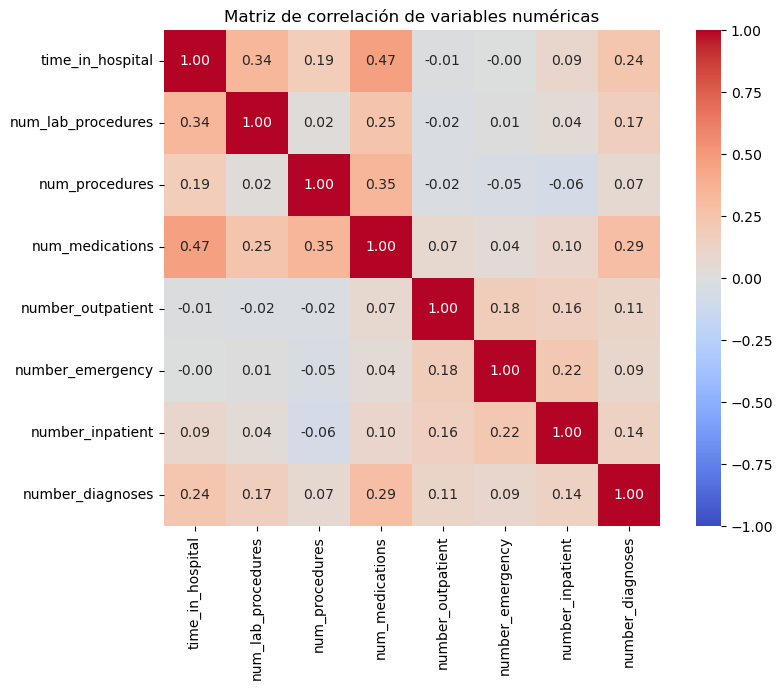

In [24]:
correlacion_numericas = df[columnas_numericas].corr(method = 'spearman')
display(correlacion_numericas.round(2))

# Heatmap de correlación para verlo visualmente
plt.figure(figsize = (9,7))
sns.heatmap(correlacion_numericas, annot=True, cmap='coolwarm', fmt='.2f', center=0, vmax=1, vmin=-1, square = True)
plt.title('Matriz de correlación de variables numéricas')
plt.tight_layout()
plt.show()

#### Interpretación: no hay redundancia entre las numéricas

**La correlación más alta de la matriz es 0,47**, entre `time_in_hospital` y `num_medications`: a más
días de ingreso, más medicación acumulada. Es una relación lógica y moderada, a medio camino entre
la ausencia de relación y la correlación perfecta, y queda por debajo incluso del umbral de
vigilancia (0,5). Ninguna variable sobra por este motivo.

**Las tres variables de historial son tres cosas distintas.** `number_outpatient`,
`number_emergency` y `number_inpatient` se correlacionan entre sí a 0,16, 0,18 y 0,22. El paciente
que acude mucho a urgencias no es, en general, el que acumula ingresos previos ni el que frecuenta
las consultas externas: son tres perfiles de uso del sistema sanitario. Es el resultado más
importante del apartado, porque eran las tres variables más discriminantes de la sección 3 y
podrían haber sido una sola con tres nombres. No lo son: las tres aportan.

**El único bloque con correlaciones apreciables es el del ingreso actual.** `time_in_hospital`,
`num_medications`, `num_lab_procedures`, `num_procedures` y `number_diagnoses` se relacionan entre
sí entre 0,2 y 0,47, y el mapa de calor lo muestra como la única zona coloreada de la matriz. Tiene
sentido: describen la misma estancia, y un ingreso largo tiene más análisis, más fármacos y más
diagnósticos. Pero ninguna pareja supera 0,5.

**No hay correlaciones negativas que interpretar.** La más baja es −0,06 (`num_procedures` con
`number_inpatient`); el resto está entre −0,05 y 0.

**Conclusión del 6.1: las ocho variables numéricas aportan información distinta y se conservan
todas.** Sobre el mapa de calor: no ha mostrado nada que la tabla no tuviera, y así estaba previsto;
su aportación es de lectura —con 64 números, ver de un vistazo que solo hay un bloque coloreado y
que el del historial es gris es más rápido que recorrerlos—, y esa es la justificación con la que se
incluye, no la costumbre.

### 6.2 · Redundancias entre variables categóricas

La correlación de Spearman no se aplica a categóricas: no hay valores que ordenar. Para saber si dos
categóricas repiten información se usa la herramienta de la sección 5, la tabla cruzada, pero
**entre las dos variables en lugar de contra el objetivo**. Si conociendo una se puede adivinar la
otra, son redundantes.

No se comprueban todos los pares posibles —serían más de trescientos— sino los dos que el apartado
5.6 dejó señalados, porque en ambos hay un motivo concreto para sospechar:

| Par | Sospecha | Pregunta que resuelve la tabla |
|---|---|---|
| `change` y `insulin` | `change` indica si se modificó *alguna* medicación, e `insulin` es la más modificada de todas | ¿Es `change = Ch` casi siempre un ajuste de insulina? Si sí, `change` no añade nada |
| `payer_code` y `age` | `MC` (Medicare) es el seguro de los mayores de 65 años | ¿Es `payer_code = MC` simplemente otra forma de decir "mayor de 65"? |

En cada caso, la tabla cruzada normalizada por filas (`normalize='index'`) dirá qué porcentaje de
cada categoría de una variable cae en cada categoría de la otra. Redundancia sería ver filas con un
valor cercano al 100%: "todos los `Ch` son ajustes de insulina", "todos los `MC` tienen más de 65
años". Un reparto más mezclado significa que cada variable conserva información propia.

In [25]:
cross1 = pd.crosstab(df['change'], df['insulin'], normalize='index') * 100
cross2 = pd.crosstab(df['payer_code'], df['age'], normalize='index') * 100
display(cross1.round(2))
display(cross2.round(2))



insulin,Down,No,Steady,Up
change,,,,
Ch,25.99,18.91,31.03,24.07
No,0.00,70.30,29.70,0.00


age,[0-10),[10-20),[20-30),[30-40),[40-50),[50-60),[60-70),[70-80),[80-90),[90-100)
payer_code,,,,,,,,,,
BC,0.13,0.82,2.34,6.17,16.91,36.54,28.85,5.05,2.88,0.32
CH,0.00,1.37,1.37,2.05,8.90,23.97,37.67,15.07,9.59,0.00
CM,0.00,0.05,0.26,0.83,5.06,9.65,24.52,37.33,18.90,3.41
CP,0.12,0.79,2.41,4.90,17.21,29.69,28.98,10.23,5.09,0.59
DM,0.00,2.91,8.38,17.30,28.96,25.68,15.85,0.73,0.18,0.00
FR,0.00,0.00,0.00,0.00,0.00,0.00,100.00,0.00,0.00,0.00
HM,0.00,0.49,2.42,6.15,14.78,25.80,25.44,16.74,7.33,0.84
MC,0.00,0.00,0.20,0.88,3.04,6.56,19.86,35.70,28.70,5.05
MD,0.06,1.81,7.19,10.56,18.04,26.67,19.56,8.21,6.26,1.64


#### Interpretación

**`change` e `insulin` no son redundantes.** En la fila `Ch`, los ajustes de insulina (`Up` + `Down`)
suman el **50,06%**: la mitad de los pacientes con "medicación cambiada" tuvieron un ajuste de
insulina, y **la otra mitad tiene la insulina en `No` o `Steady`**, de modo que el cambio fue en otro
fármaco. `change` recoge información que `insulin` no contiene. La fila `No` aporta además una
comprobación de coherencia: 0,00% en `Up` y en `Down`; si no se cambió nada, la insulina no se movió.
Las dos variables están bien definidas y se conservan.

El resultado encaja con lo visto en la sección 5: la mitad de `Ch` que no corresponde a insulina son
ajustes de antidiabéticos orales, que en el apartado 5.4 no discriminaban. Por eso `change` (11,82%
de `<30`) es más débil que `insulin` en `Up`/`Down` (13-14%): está diluida con cambios que no
importan para el objetivo.

**`payer_code` y `age`: redundancia parcial.** En la fila `MC` (Medicare), los tramos de 60 años en
adelante suman el **89,3%**, y los de 70 en adelante el 69,5%. Medicare es, en efecto, edad. Pero no
del todo: un 10,7% de sus pacientes tiene menos de 60 años (Medicare cubre también discapacidad). Y
la relación no funciona a la inversa: los mayores no son todos `MC` —`Unknown` tiene un 42% de
pacientes de 70 años o más, `CM` un 60%—, así que conocer la edad no permite adivinar la
aseguradora. `payer_code` conserva información propia (seguro privado, Medicaid, desconocido),
aunque su valor frente al objetivo fue débil en el 5.5.

**Conclusión del 6.2.** Ninguna de las dos parejas justifica eliminar una variable por
redundancia. Si `payer_code` acaba fuera del modelo, será por su escasa capacidad discriminante y
su 40% de `Unknown`, no por repetir a `age`.

### 6.3 · Tabla final de variables

Se reúnen aquí los veredictos de las secciones 3 (numéricas), 5 (categóricas) y 6 (redundancias) en
una única tabla. Es el resultado del EDA que la fase de preparación tomará como punto de partida:
qué variables entran con expectativas, cuáles entran sin ellas, cuáles se proponen eliminar y cuáles
requieren un tratamiento previo. Las decisiones se ejecutan en el notebook 04, cada una con la
evidencia que aquí se cita.

| Grupo | Variables | Evidencia | Tratamiento previsto |
|---|---|---|---|
| **Prometedoras** | `number_inpatient` | Media 1,22 / 0,84 / 0,38 (3,2×); el 50% de `<30` tiene ≥1 | Entra tal cual |
| | `discharge_disposition_id` | `<30` de 9,30 a 27,70 entre categorías con miles de pacientes | Excluir fallecidos y hospice; agrupar categorías <100 en `Otros` |
| | `insulin` | `No` 10,04 → `Down` 13,90; el ajuste cubre al 23% | Encoding **nominal**, no ordinal |
| | `number_emergency` | 3,3×, pero solo el 17% tiene ≥1 | Entra tal cual |
| **Moderadas** | `max_glu_serum` | Escalera hasta 14,32 en `>300` (N = 1.264) | Entra tal cual |
| | `diabetesMed`, `metformin` | 9,60 vs 11,63; `Steady` 9,71 vs `No` 11,52 | Entran tal cual |
| | `number_outpatient`, `num_medications`, `time_in_hospital`, `number_diagnoses` | Dirección coherente `<30` ≥ `>30` ≥ `NO`, diferencias pequeñas | Entran tal cual |
| **Débiles** | `age`, `A1Cresult`, `change`, `admission_type_id`, `admission_source_id`, `payer_code`, `num_procedures`, `num_lab_procedures`, `glipizide`, `glyburide`, `glimepiride`, `pioglitazone`, `rosiglitazone`, `repaglinide` | Diferencias de uno o dos puntos, o concentradas en `>30` | Entran; `admission_type_id` agrupa códigos 4 y 7 en `Otros`; los `*_id` y `payer_code` agrupan categorías <100 |
| **Candidatas a eliminar** | `gender`, `race` | 0,18 puntos; grupos mayoritarios idénticos, desvío de `Unknown` artefactual | Eliminar en el 04, con esta justificación |
| | `nateglinide`, `acarbose`, `glyburide-metformin` | Ninguna situación distinta de `No` supera los 700 pacientes | Eliminar en el 04 |
| **Pendientes de agrupación** | `diag_1`, `diag_2`, `diag_3`, `medical_specialty` | Cardinalidad 73-789; no cruzadas con el objetivo | Agrupar (capítulos CIE-9) en el 04 y evaluar entonces |

**Redundancias:** ninguna. Máxima correlación entre numéricas 0,47; `change`/`insulin` y
`payer_code`/`age` conservan información propia.

**Sobre las tres variables de historial**, que son el núcleo de la señal: la matriz de correlación
confirma que son tres perfiles distintos (0,16-0,22 entre sí), de modo que las tres entran y ninguna
es prescindible por parecerse a otra.

## 7 · Conclusiones globales del EDA

### 7.1 · Qué se ha hecho

Sobre el dataset limpio del notebook 02 (101.766 ingresos × 35 columnas) se ha analizado la variable
objetivo, las ocho variables numéricas y las veintisiete categóricas, primero cada una por separado
y después frente a `readmitted`; por último, las variables entre sí para detectar redundancias. Cada
tabla y cada gráfica lleva su justificación previa y su interpretación posterior, y las decisiones
que el análisis deja preparadas se han recogido en la tabla del apartado 6.3.

### 7.2 · Lo que anticipa la readmisión precoz

La distribución de la variable objetivo fija el marco: el 53,91% de los ingresos no se sigue de
readmisión, el 34,93% se readmite después de 30 días y solo el **11,16%** antes de 30 días, que es
la clase clínicamente relevante y la minoritaria. Un modelo que prediga siempre `NO` acierta el 54%
sin aprender nada; por eso la evaluación se hará con *precision*, *recall* y F1 sobre `<30`, no con
*accuracy*.

Las variables que más separan a los pacientes readmitidos antes de 30 días se agrupan en tres
ideas:

1. **Fragilidad.** El destino al alta (`discharge_disposition_id`) es la variable más discriminante
   del EDA: los pacientes que vuelven a casa por su pie reingresan un 9,30%, los que van a una
   residencia un 14,66%, los que van a rehabilitación un 27,70%. El historial de ingresos previos
   (`number_inpatient`) es la mejor numérica: media de 1,22 en `<30` frente a 0,38 en `NO`, y la
   mitad de los readmitidos precoces tiene al menos uno.
2. **Inestabilidad del tratamiento.** El ajuste de insulina en cualquier dirección (`insulin` en
   `Up` o `Down`, 13-14% frente al 10-11% de `No`/`Steady`) y una glucemia aguda elevada
   (`max_glu_serum` `>300`, 14,32%) señalan al paciente descompensado.
3. **Seguimiento, en sentido contrario.** Medir la HbA1c (`A1Cresult`), con independencia del
   resultado, y llevar un antidiabético oral estable (`metformin` en `Steady`) se asocian a menos
   reingreso. El primero reproduce la conclusión del estudio original del dataset (Strack et al.,
   2014).

Las variables demográficas y administrativas apenas aportan: `gender` y `race` no discriminan, y
`age`, `admission_type_id`, `admission_source_id` y `payer_code` mueven el porcentaje uno o dos
puntos.

**La señal es real pero modesta.** Las mejores variables separan las clases por unos pocos puntos
porcentuales; ninguna, por sí sola, predice la readmisión. Un resultado de modelado discreto no será
un fallo del análisis: la readmisión depende de factores que el dataset no recoge (situación
social, adherencia al tratamiento, evolución tras el alta), y el valor de este proyecto está en
explicar qué se puede predecir con lo que hay y por qué no más.

### 7.3 · Lo que el EDA ha descubierto sobre el dataset

Tres limitaciones que no estaban en la documentación y que condicionan la interpretación de
cualquier modelo:

- **Solo registra los reingresos dentro de la misma red hospitalaria.** Tres indicios
  independientes: los pacientes con `race = Unknown` tienen la mitad de historial y un 68% de `NO`;
  los trasladados desde otros centros, un `NO` del 69-73%; y parte del 27,70% de rehabilitación
  puede ser el circuito de traslados. Un paciente que reingresa en otro hospital figura como `NO`.
- **Los códigos de dato ausente identifican hospitales, no pacientes.** El código 6 de
  `admission_type_id` coincide al 99,92% con `payer_code = Unknown`. Conservar `Unknown` como
  categoría fue correcto, pero informa de la procedencia del registro: un modelo que lo use
  aprende "en qué hospital estuvo el paciente".
- **La clase `NO` contiene fallecidos.** 1.652 con código explícito, 771 en hospice y un número
  desconocido de muertes posteriores al alta sin código, como sugiere el tramo `[90-100)`, que
  solo se corrige en parte al excluir los códigos.

Y dos hallazgos metodológicos que cambian cómo se preparan los datos:

- **`insulin` no es ordinal.** Su estructura real es *sin / estable / modificada*; el orden fijado
  en el apartado 4.2 como progresión de dosis era erróneo, y un encoding ordinal lo sería también.
- **El patrón de `insulin` no se generaliza a los antidiabéticos orales**, donde el ajuste de dosis
  no discrimina.

### 7.4 · Las cuestiones abiertas y su estado

| Cuestión | Estado tras el EDA | Se resuelve en |
|---|---|---|
| **Pacientes fallecidos** | Evidencia obtenida: 1.652 con `readmitted = NO` al 100%, más 771 en hospice con 86-92%. Decisión preparada: excluir los códigos 11, 19, 20, 21, 13 y 14 (2.423 filas) | Notebook 04 |
| **Duplicidad de pacientes** | 101.766 ingresos de 71.518 pacientes; un paciente llega a 40 ingresos. `patient_nbr` se recupera del original por orden de fila. Pendiente elegir entre quedarse con un ingreso por paciente o partir agrupando por paciente | Notebook 04 |
| **Alta cardinalidad** | `diag_1/2/3` (716-789) y `medical_specialty` (73) sin analizar frente al objetivo. Vía prevista: capítulos CIE-9. Además, categorías <100 en los tres `*_id` y `payer_code` a `Otros` | Notebook 04 |
| **Formulación del objetivo** | Sin decidir. El EDA aporta un argumento: en varias variables la señal está en `>30` y no en `<30` (`age`, `number_outpatient`), de modo que la formulación binaria (`<30` frente al resto) descarta información, pero es la pregunta clínica | Notebook 04 |

### 7.5 · Lo que sigue

El **notebook 04 (preparación)** parte de `diabetic_data_clean.csv` y de la tabla del apartado 6.3,
y ejecuta, con su justificación, cada decisión que este análisis ha dejado preparada: exclusión de
fallecidos y hospice, agrupación de categorías, eliminación de las variables sin señal, encoding
nominal de los fármacos, recuperación de `patient_nbr` y partición sin fuga, y la formulación
definitiva del objetivo. Termina guardando los conjuntos de entrenamiento y prueba.

Con el notebook 04 **termina este proyecto**, cuyo alcance es la limpieza, el análisis exploratorio y
la preparación del dataset. El modelado —línea base, regresión logística, modelos de árboles,
evaluación con métricas adecuadas a una clase minoritaria e interpretación— se aborda en un proyecto
posterior que partirá de los conjuntos de entrenamiento y prueba que el 04 deje guardados.